# Part 1: 01 Data Quality Audit

# Notebook 01 — Data Quality Audit

**Tier:** Pre-analytics  
**Purpose:** Document every data quality issue in the raw CSV before any cleaning.  
**Input:** `Data/ncr_ride_bookings.csv` (read-only, never modified)  
**Output:** `outputs/reports/data_quality_summary.csv`  
**Caveats:** All numeric ranges and distributions are observed from the actual data — no prior assumptions are encoded.

In [5]:
import warnings
import pathlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')
pathlib.Path('outputs/reports').mkdir(parents=True, exist_ok=True)
pathlib.Path('outputs/plots').mkdir(parents=True, exist_ok=True)

RAW_PATH = 'Data/ncr_ride_bookings.csv'
print(f'Reading: {RAW_PATH}')

Reading: Data/ncr_ride_bookings.csv


## 1. Raw Schema Overview

In [6]:
# Read all columns as strings to preserve raw values (no type coercion)
import os
os.chdir(r"D:\projects\Uber_Data_India_Analytics")

print("Working directory:", os.getcwd())
raw = pd.read_csv(RAW_PATH, dtype=str, keep_default_na=False)

print(f'Shape: {raw.shape}')
print(f'Columns ({len(raw.columns)}):')
for col in raw.columns:
    print(f'  {col!r:45s}  sample: {raw[col].iloc[0]!r}')

Working directory: D:\projects\Uber_Data_India_Analytics
Shape: (150000, 21)
Columns (21):
  'Date'                                         sample: '2024-03-23'
  'Time'                                         sample: '12:29:38'
  'Booking ID'                                   sample: '"CNR5884300"'
  'Booking Status'                               sample: 'No Driver Found'
  'Customer ID'                                  sample: '"CID1982111"'
  'Vehicle Type'                                 sample: 'eBike'
  'Pickup Location'                              sample: 'Palam Vihar'
  'Drop Location'                                sample: 'Jhilmil'
  'Avg VTAT'                                     sample: 'null'
  'Avg CTAT'                                     sample: 'null'
  'Cancelled Rides by Customer'                  sample: 'null'
  'Reason for cancelling by Customer'            sample: 'null'
  'Cancelled Rides by Driver'                    sample: 'null'
  'Driver Cancellation Reason

## 2. Row Count & Duplicates

In [7]:
EXPECTED = 150_000
actual = len(raw)
print(f'Expected rows : {EXPECTED:,}')
print(f'Actual rows   : {actual:,}')
if actual != EXPECTED:
    print(f'  ⚠ Deviation: {actual - EXPECTED:+,} rows')
else:
    print('  ✓ Row count matches expected.')

# Duplicate Booking IDs (raw string, before stripping quotes)
dup_ids = raw['Booking ID'].duplicated()
print(f'\nDuplicate Booking IDs: {dup_ids.sum()}')
if dup_ids.sum() > 0:
    print(raw[dup_ids | raw['Booking ID'].isin(raw[dup_ids]['Booking ID'])][['Booking ID','Booking Status','Date']].head())

Expected rows : 150,000
Actual rows   : 150,000
  ✓ Row count matches expected.

Duplicate Booking IDs: 1233
       Booking ID Booking Status        Date
146  "CNR2687237"      Completed  2024-04-15
248  "CNR5380412"      Completed  2024-02-01
317  "CNR5071968"      Completed  2024-10-10
397  "CNR2290384"      Completed  2024-04-28
493  "CNR3466923"      Completed  2024-02-11


## 3. Triple-Quote Encoding Issue

In [8]:
print('Sample Booking ID values (raw):')
print(raw['Booking ID'].head(3).tolist())
print('\nSample Customer ID values (raw):')
print(raw['Customer ID'].head(3).tolist())

triple_quoted_bids = raw['Booking ID'].str.startswith('"""').sum()
triple_quoted_cids = raw['Customer ID'].str.startswith('"""').sum()
print(f'\nTriple-quoted Booking IDs : {triple_quoted_bids:,} / {len(raw):,}')
print(f'Triple-quoted Customer IDs: {triple_quoted_cids:,} / {len(raw):,}')

Sample Booking ID values (raw):
['"CNR5884300"', '"CNR1326809"', '"CNR8494506"']

Sample Customer ID values (raw):
['"CID1982111"', '"CID4604802"', '"CID9202816"']

Triple-quoted Booking IDs : 0 / 150,000
Triple-quoted Customer IDs: 0 / 150,000


## 4. "null" String vs True NaN

In [9]:
null_str_counts = (raw == 'null').sum().rename('null_string_count')
empty_counts = (raw == '').sum().rename('empty_count')
null_summary = pd.concat([null_str_counts, empty_counts], axis=1)
null_summary['total_missing'] = null_summary.sum(axis=1)
null_summary['missing_pct'] = (null_summary['total_missing'] / len(raw) * 100).round(1)
print('Missing value counts per column ("null" strings + empty strings):')
print(null_summary.sort_values('total_missing', ascending=False).to_string())

null_summary.to_csv('outputs/reports/data_quality_summary.csv')
print('\nSaved: outputs/reports/data_quality_summary.csv')

Missing value counts per column ("null" strings + empty strings):
                                   null_string_count  empty_count  total_missing  missing_pct
Incomplete Rides Reason                       141000            0         141000         94.0
Incomplete Rides                              141000            0         141000         94.0
Reason for cancelling by Customer             139500            0         139500         93.0
Cancelled Rides by Customer                   139500            0         139500         93.0
Cancelled Rides by Driver                     123000            0         123000         82.0
Driver Cancellation Reason                    123000            0         123000         82.0
Driver Ratings                                 57000            0          57000         38.0
Customer Rating                                57000            0          57000         38.0
Avg CTAT                                       48000            0          48000        

## 5. Null Alignment Validation

In [10]:
# Check structural null patterns against Booking Status
status_col = 'Booking Status'
check_cols = ['Booking Value', 'Ride Distance', 'Payment Method',
              'Driver Ratings', 'Customer Rating']

print('Non-null counts by Booking Status for post-outcome columns:')
for col in check_cols:
    mask_present = (raw[col] != 'null') & (raw[col] != '')
    tbl = raw[mask_present].groupby(status_col).size().rename(col)
    print(f'\n  {col}:')
    print(tbl.to_string())

print('\n--- VTAT null by status ---')
vtat_null = (raw['Avg VTAT'] == 'null') | (raw['Avg VTAT'] == '')
print(raw[vtat_null].groupby(status_col).size())

print('\n--- CTAT null by status ---')
ctat_null = (raw['Avg CTAT'] == 'null') | (raw['Avg CTAT'] == '')
print(raw[ctat_null].groupby(status_col).size())

Non-null counts by Booking Status for post-outcome columns:

  Booking Value:
Booking Status
Completed     93000
Incomplete     9000

  Ride Distance:
Booking Status
Completed     93000
Incomplete     9000

  Payment Method:
Booking Status
Completed     93000
Incomplete     9000

  Driver Ratings:
Booking Status
Completed    93000

  Customer Rating:
Booking Status
Completed    93000

--- VTAT null by status ---
Booking Status
No Driver Found    10500
dtype: int64

--- CTAT null by status ---
Booking Status
Cancelled by Customer    10500
Cancelled by Driver      27000
No Driver Found          10500
dtype: int64


## 6. Booking Status Distribution

Booking Status distribution:
                       count   pct
Booking Status                    
Completed              93000  62.0
Cancelled by Driver    27000  18.0
No Driver Found        10500   7.0
Cancelled by Customer  10500   7.0
Incomplete              9000   6.0


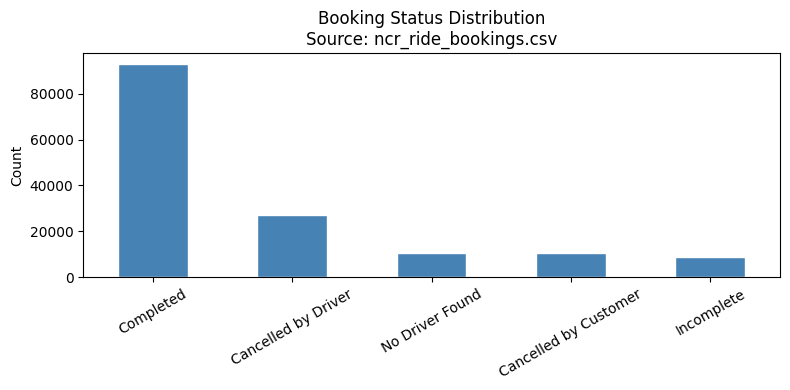

In [11]:
status_counts = raw['Booking Status'].value_counts()
status_pct = (status_counts / len(raw) * 100).round(1)
status_df = pd.DataFrame({'count': status_counts, 'pct': status_pct})
print('Booking Status distribution:')
print(status_df.to_string())

fig, ax = plt.subplots(figsize=(8, 4))
status_counts.plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')
ax.set_title('Booking Status Distribution\nSource: ncr_ride_bookings.csv')
ax.set_xlabel('')
ax.set_ylabel('Count')
ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
fig.savefig('outputs/plots/01_booking_status.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Numeric Distributions (Observed — Not Assumed)

In [12]:
num_cols = ['Avg VTAT', 'Avg CTAT', 'Booking Value', 'Ride Distance',
            'Driver Ratings', 'Customer Rating']

percentile_rows = []
for col in num_cols:
    vals = pd.to_numeric(raw[col].replace({'null': np.nan, '': np.nan}), errors='coerce').dropna()
    if len(vals) == 0:
        continue
    row = {
        'column': col, 'count': len(vals),
        'min': vals.min(), 'p25': vals.quantile(0.25), 'p50': vals.median(),
        'p75': vals.quantile(0.75), 'p95': vals.quantile(0.95), 'max': vals.max(),
        'mean': vals.mean().round(3)
    }
    percentile_rows.append(row)

perc_df = pd.DataFrame(percentile_rows).set_index('column')
print('Observed numeric distributions (from actual data):')
print(perc_df.round(2).to_string())
perc_df.to_csv('outputs/reports/numeric_distributions.csv')

Observed numeric distributions (from actual data):
                  count   min     p25     p50     p75      p95     max    mean
column                                                                        
Avg VTAT         139500   2.0    5.30    8.30   11.30    14.60    20.0    8.46
Avg CTAT         102000  10.0   21.60   28.80   36.80    43.40    45.0   29.15
Booking Value    102000  50.0  234.00  414.00  689.00  1224.00  4277.0  508.30
Ride Distance    102000   1.0   12.46   23.72   36.82    47.35    50.0   24.64
Driver Ratings    93000   3.0    4.10    4.30    4.60     4.90     5.0    4.23
Customer Rating   93000   3.0    4.20    4.50    4.80     5.00     5.0    4.40


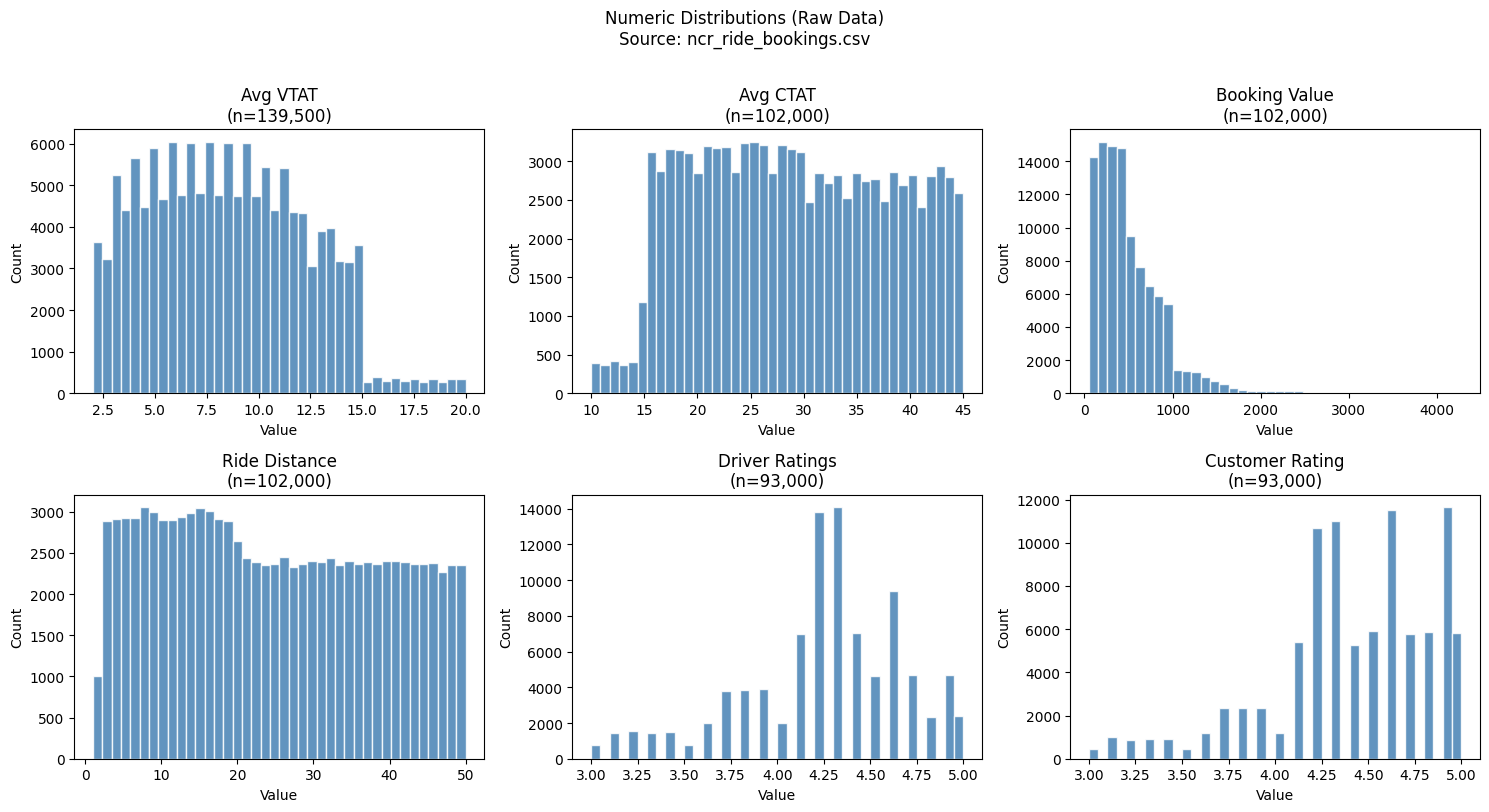

In [13]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()
for i, col in enumerate(num_cols):
    vals = pd.to_numeric(raw[col].replace({'null': np.nan, '': np.nan}), errors='coerce').dropna()
    ax = axes[i]
    ax.hist(vals, bins=40, color='steelblue', edgecolor='white', alpha=0.85)
    ax.set_title(f'{col}\n(n={len(vals):,})')
    ax.set_xlabel('Value')
    ax.set_ylabel('Count')
fig.suptitle('Numeric Distributions (Raw Data)\nSource: ncr_ride_bookings.csv', y=1.01)
plt.tight_layout()
fig.savefig('outputs/plots/01_numeric_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Categorical Cardinality

In [14]:
cat_cols = ['Vehicle Type', 'Payment Method', 'Reason for cancelling by Customer',
            'Driver Cancellation Reason', 'Incomplete Rides Reason']
for col in cat_cols:
    vals = raw[col][~raw[col].isin(['null', ''])]
    print(f'\n{col} ({vals.nunique()} unique, {len(vals):,} non-null):')
    print(vals.value_counts().to_string())


Vehicle Type (7 unique, 150,000 non-null):
Vehicle Type
Auto             37419
Go Mini          29806
Go Sedan         27141
Bike             22517
Premier Sedan    18111
eBike            10557
Uber XL           4449

Payment Method (5 unique, 102,000 non-null):
Payment Method
UPI            45909
Cash           25367
Uber Wallet    12276
Credit Card    10209
Debit Card      8239

Reason for cancelling by Customer (5 unique, 10,500 non-null):
Reason for cancelling by Customer
Wrong Address                                   2362
Change of plans                                 2353
Driver is not moving towards pickup location    2335
Driver asked to cancel                          2295
AC is not working                               1155

Driver Cancellation Reason (4 unique, 27,000 non-null):
Driver Cancellation Reason
Customer related issue                 6837
The customer was coughing/sick         6751
Personal & Car related issues          6726
More than permitted people in there  

## 9. Location Cardinality

In [15]:
print(f'Unique Pickup Locations : {raw["Pickup Location"].nunique()}')
print(f'Unique Drop Locations   : {raw["Drop Location"].nunique()}')
print(f'Unique routes (P→D pairs): {(raw["Pickup Location"] + " → " + raw["Drop Location"]).nunique()}')
print('\nTop 10 Pickup Locations:')
print(raw['Pickup Location'].value_counts().head(10).to_string())

Unique Pickup Locations : 176
Unique Drop Locations   : 176
Unique routes (P→D pairs): 30564

Top 10 Pickup Locations:
Pickup Location
Khandsa             949
Barakhamba Road     946
Saket               931
Badarpur            921
Pragati Maidan      920
Madipur             919
AIIMS               918
Mehrauli            915
Dwarka Sector 21    914
Pataudi Chowk       907


## 10. Date Range & Continuity

In [16]:
dates = pd.to_datetime(raw['Date'], errors='coerce')
print(f'Date min : {dates.min().date()}')
print(f'Date max : {dates.max().date()}')
months_present = dates.dt.to_period('M').unique()
print(f'Months present ({len(months_present)}): {sorted(str(m) for m in months_present)}')
if len(months_present) < 12:
    print('  ⚠ Some months missing from 2024 calendar year.')
else:
    print('  ✓ All 12 months of 2024 present.')

Date min : 2024-01-01
Date max : 2024-12-30
Months present (12): ['2024-01', '2024-02', '2024-03', '2024-04', '2024-05', '2024-06', '2024-07', '2024-08', '2024-09', '2024-10', '2024-11', '2024-12']
  ✓ All 12 months of 2024 present.


## 11. Quality Issue Summary

| Issue | Affected Rows | Planned Fix |
|---|---|---|
| Triple-quoted Booking ID / Customer ID | All 150,000 | Strip `"""` in cleaning |
| `"null"` strings instead of true NaN | ~48,000–57,000 depending on column | Replace with `np.nan` |
| `Booking Value` / `Ride Distance` / `Payment Method` null for non-Completed | ~57,000 (structural) | Document as by-design; do not impute |
| `Driver Ratings` / `Customer Rating` null for non-Completed | ~57,000 (structural) | Document; do not impute |
| `Avg CTAT` null for No Driver Found + all cancellations | ~48,000 (structural) | Document; impute training median in ML pipeline only |
| Date/Time are separate string columns | All rows | Combine → `datetime` during cleaning |

## Limitations
- No driver ID field → cannot analyse individual driver behaviour.
- No cost fields (payout, commission, operating cost) → CAC, LTV, ROAS, contribution margin cannot be calculated.
- No acquisition channel field → customer origin is unknown.

# Part 2: 02 Data Cleaning

# Notebook 02 — Data Cleaning

**Tier:** Pre-analytics  
**Purpose:** Apply all cleaning transforms and produce the canonical cleaned dataset.  
**Input:** `Data/ncr_ride_bookings.csv` (read-only)  
**Output:** `outputs/cleaned_data.parquet`  
**Caveats:**  
- Nulls in Booking Value / Ride Distance / Payment Method for non-Completed rides are **structural** — they are not imputed.  
- Driver/Customer Ratings nulls are not imputed — missing = ride did not produce a rating.  
- Raw CSV hash is verified before and after to guarantee no modification.

In [4]:
import sys
sys.path.insert(0, '..')

import warnings
import pathlib
import pandas as pd
import numpy as np

warnings.filterwarnings('ignore')
pathlib.Path('outputs').mkdir(exist_ok=True)

## 1. Run Cleaning Pipeline

In [5]:
import os
os.chdir(r"D:\projects\Uber_Data_India_Analytics")
from src.data_loader import load_clean

df = load_clean(force_rebuild=True)
print(f'\nCleaned shape: {df.shape}')

[OK] Row count: 150,000
[OK] 'Booking Value' null alignment correct for cancelled/no-driver statuses.
[OK] 'Ride Distance' null alignment correct for cancelled/no-driver statuses.
[OK] 'Payment Method' null alignment correct for cancelled/no-driver statuses.
[OK] 'Avg VTAT' null alignment: only 'No Driver Found' rows.
  Sample duplicates:
     Booking ID            datetime Booking Status
146  CNR2687237 2024-04-15 19:03:28      Completed
248  CNR5380412 2024-02-01 09:13:13      Completed
317  CNR5071968 2024-10-10 03:56:19      Completed
397  CNR2290384 2024-04-28 01:17:51      Completed
493  CNR3466923 2024-02-11 17:05:28      Completed

[NULL SUMMARY]
                                   null_count  null_pct
Incomplete Rides                       141000      94.0
Incomplete Rides Reason                141000      94.0
Cancelled Rides by Customer            139500      93.0
Reason for cancelling by Customer      139500      93.0
Cancelled Rides by Driver              123000      82.0
D

## 2. Dtypes After Cleaning

In [6]:
print(df.dtypes.to_string())

Date                                         object
Time                                         object
Booking ID                                   object
Booking Status                             category
Customer ID                                  object
Vehicle Type                               category
Pickup Location                              object
Drop Location                                object
Avg VTAT                                    float64
Avg CTAT                                    float64
Cancelled Rides by Customer                    Int8
Reason for cancelling by Customer            object
Cancelled Rides by Driver                      Int8
Driver Cancellation Reason                   object
Incomplete Rides                               Int8
Incomplete Rides Reason                      object
Booking Value                               float64
Ride Distance                               float64
Driver Ratings                              float64
Customer Rat

## 3. Null Summary After Cleaning

In [7]:
null_counts = df.isna().sum()
null_pct = (null_counts / len(df) * 100).round(1)
null_df = pd.DataFrame({'null_count': null_counts, 'null_pct': null_pct})
null_df = null_df[null_df['null_count'] > 0].sort_values('null_count', ascending=False)
print('Remaining nulls (all are structurally expected):')
print(null_df.to_string())

Remaining nulls (all are structurally expected):
                                   null_count  null_pct
Incomplete Rides                       141000      94.0
Incomplete Rides Reason                141000      94.0
Cancelled Rides by Customer            139500      93.0
Reason for cancelling by Customer      139500      93.0
Cancelled Rides by Driver              123000      82.0
Driver Cancellation Reason             123000      82.0
Driver Ratings                          57000      38.0
Customer Rating                         57000      38.0
Avg CTAT                                48000      32.0
Ride Distance                           48000      32.0
Booking Value                           48000      32.0
Payment Method                          48000      32.0
Avg VTAT                                10500       7.0


## 4. Verify No "null" Strings Remain

In [8]:
str_cols = df.select_dtypes(include='object').columns
null_str_remaining = {c: (df[c] == 'null').sum() for c in str_cols if (df[c] == 'null').sum() > 0}
if null_str_remaining:
    print(f'⚠ Remaining "null" strings: {null_str_remaining}')
else:
    print('✓ No "null" strings remain in any column.')

✓ No "null" strings remain in any column.


## 5. Verify Booking ID Strip

In [9]:
triple_q = df['Booking ID'].str.startswith('"', na=False).sum()
print(f'Booking IDs still containing quotes: {triple_q}')
print('Sample Booking IDs after cleaning:')
print(df['Booking ID'].head(5).tolist())

Booking IDs still containing quotes: 0
Sample Booking IDs after cleaning:
['CNR5884300', 'CNR1326809', 'CNR8494506', 'CNR8906825', 'CNR1950162']


## 6. Structural Null Alignment Check

In [10]:
print('Booking Value non-null by status (expect: Completed only):')
print(df.dropna(subset=['Booking Value']).groupby('Booking Status', observed=True).size())

print('\nPayment Method non-null by status (expect: Completed only):')
print(df.dropna(subset=['Payment Method']).groupby('Booking Status', observed=True).size())

print('\nAvg VTAT null by status (expect: No Driver Found only):')
print(df[df['Avg VTAT'].isna()].groupby('Booking Status', observed=True).size())

Booking Value non-null by status (expect: Completed only):
Booking Status
Completed     93000
Incomplete     9000
dtype: int64

Payment Method non-null by status (expect: Completed only):
Booking Status
Completed     93000
Incomplete     9000
dtype: int64

Avg VTAT null by status (expect: No Driver Found only):
Booking Status
No Driver Found    10500
dtype: int64


## 7. Observed Numeric Ranges (Post-Clean)

In [11]:
num_cols = ['Avg VTAT', 'Avg CTAT', 'Booking Value', 'Ride Distance', 'Driver Ratings', 'Customer Rating']
print(df[num_cols].describe(percentiles=[0.25, 0.5, 0.75, 0.95]).round(2).to_string())

        Avg VTAT   Avg CTAT  Booking Value  Ride Distance  Driver Ratings  Customer Rating
count  139500.00  102000.00      102000.00      102000.00        93000.00         93000.00
mean        8.46      29.15         508.30          24.64            4.23             4.40
std         3.77       8.90         395.81          14.00            0.44             0.44
min         2.00      10.00          50.00           1.00            3.00             3.00
25%         5.30      21.60         234.00          12.46            4.10             4.20
50%         8.30      28.80         414.00          23.72            4.30             4.50
75%        11.30      36.80         689.00          36.82            4.60             4.80
95%        14.60      43.40        1224.00          47.35            4.90             5.00
max        20.00      45.00        4277.00          50.00            5.00             5.00


## 8. Completed Rides with Null Booking Value (Integrity Violations)

In [12]:
import pathlib
q_path = pathlib.Path('outputs/completed_nullfare_quarantine.csv')
if q_path.exists():
    quarantined = pd.read_csv(q_path)
    print(f'⚠ Quarantined rows (Completed + null Booking Value): {len(quarantined)}')
    print(quarantined.head())
else:
    print('✓ No data integrity violations found (no quarantine file created).')

✓ No data integrity violations found (no quarantine file created).


## 9. Sample of Cleaned Data

In [13]:
df.head(5)

,Date,Time,Booking ID,Booking Status,Customer ID,Vehicle Type,Pickup Location,Drop Location,Avg VTAT,Avg CTAT,...,Cancelled Rides by Driver,Driver Cancellation Reason,Incomplete Rides,Incomplete Rides Reason,Booking Value,Ride Distance,Driver Ratings,Customer Rating,Payment Method,datetime
0,2024-03-23,12:29:38,CNR5884300,No Driver Found,CID1982111,eBike,Palam Vihar,Jhilmil,NaN,NaN,...,<NA>,NaN,<NA>,NaN,NaN,NaN,NaN,NaN,NaN,2024-03-23 12:29:38
1,2024-11-29,18:01:39,CNR1326809,Incomplete,CID4604802,Go Sedan,Shastri Nagar,Gurgaon Sector 56,4.9,14.0,...,<NA>,NaN,1,Vehicle Breakdown,237.0,5.73,NaN,NaN,UPI,2024-11-29 18:01:39
2,2024-08-23,08:56:10,CNR8494506,Completed,CID9202816,Auto,Khandsa,Malviya Nagar,13.4,25.8,...,<NA>,NaN,<NA>,NaN,627.0,13.58,4.9,4.9,Debit Card,2024-08-23 08:56:10
3,2024-10-21,17:17:25,CNR8906825,Completed,CID2610914,Premier Sedan,Central Secretariat,Inderlok,13.1,28.5,...,<NA>,NaN,<NA>,NaN,416.0,34.02,4.6,5.0,UPI,2024-10-21 17:17:25
4,2024-09-16,22:08:00,CNR1950162,Completed,CID9933542,Bike,Ghitorni Village,Khan Market,5.3,19.6,...,<NA>,NaN,<NA>,NaN,737.0,48.21,4.1,4.3,UPI,2024-09-16 22:08:00


## Limitations
- Nulls in post-outcome columns (Booking Value, Ride Distance, etc.) for non-Completed rides are intentionally retained as NaN; they are never imputed.
- No rows are dropped from the cleaned dataset (except those in the integrity quarantine).
- No outlier removal is performed at this stage; outlier investigation occurs in Notebook 03.

# Part 3: 03 Eda Descriptive

# Notebook 03 — EDA / Descriptive Analytics

**Tier:** 1 — Descriptive (What happened?)  
**Purpose:** Describe ride volumes, revenue, service quality, locations, and payments.  
**Input:** `outputs/cleaned_data.parquet`  
**Output:** `outputs/feature_store.parquet`, charts in `outputs/plots/03_*`  
**Caveats:**  
- Revenue is reported as **Gross Booking Value (GBV)** — the fare paid by the customer.  
- Net revenue, driver payout, commission, and contribution margin are **unavailable** (no cost fields in dataset).  
- Per-customer cumulative revenue is reported as **Observed Customer Value (OCV)** — NOT LTV.

In [3]:
import sys
sys.path.insert(0, '..')

import warnings
import pathlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import os
os.chdir(r"D:\projects\Uber_Data_India_Analytics")

warnings.filterwarnings('ignore')
pathlib.Path('outputs/plots').mkdir(parents=True, exist_ok=True)

from src.data_loader import load_clean
from src.features import build_feature_store

df_clean = load_clean()
df = build_feature_store(df_clean, save=True)
print(f'Feature store shape: {df.shape}')

completed = df[df['is_completed']].copy()
print(f'Completed rides: {len(completed):,}')

[OK] Feature store written to outputs\feature_store.parquet  shape=(150000, 46)
Feature store shape: (150000, 46)
Completed rides: 93,000


## 3.1 Ride Volume Overview

In [4]:
total = len(df)
n_completed = (df['Booking Status'] == 'Completed').sum()
n_canc_cust = (df['Booking Status'] == 'Cancelled by Customer').sum()
n_canc_drv  = (df['Booking Status'] == 'Cancelled by Driver').sum()
n_no_drv    = (df['Booking Status'] == 'No Driver Found').sum()
n_incomplete = (df['Booking Status'] == 'Incomplete').sum()

print(f'Total bookings         : {total:,}')
print(f'Completed              : {n_completed:,}  ({n_completed/total*100:.1f}%)')
print(f'Cancelled by Customer  : {n_canc_cust:,}  ({n_canc_cust/total*100:.1f}%)')
print(f'Cancelled by Driver    : {n_canc_drv:,}  ({n_canc_drv/total*100:.1f}%)')
print(f'No Driver Found        : {n_no_drv:,}  ({n_no_drv/total*100:.1f}%)')
print(f'Incomplete             : {n_incomplete:,}  ({n_incomplete/total*100:.1f}%)')

total_gbv = completed['Booking Value'].sum()
avg_fare  = completed['Booking Value'].mean()
print(f'\nTotal Gross Booking Value (GBV) : ₹{total_gbv:,.0f}')
print(f'Avg fare per completed ride      : ₹{avg_fare:.0f}')

Total bookings         : 150,000
Completed              : 93,000  (62.0%)
Cancelled by Customer  : 10,500  (7.0%)
Cancelled by Driver    : 27,000  (18.0%)
No Driver Found        : 10,500  (7.0%)
Incomplete             : 9,000  (6.0%)

Total Gross Booking Value (GBV) : ₹47,260,574
Avg fare per completed ride      : ₹508


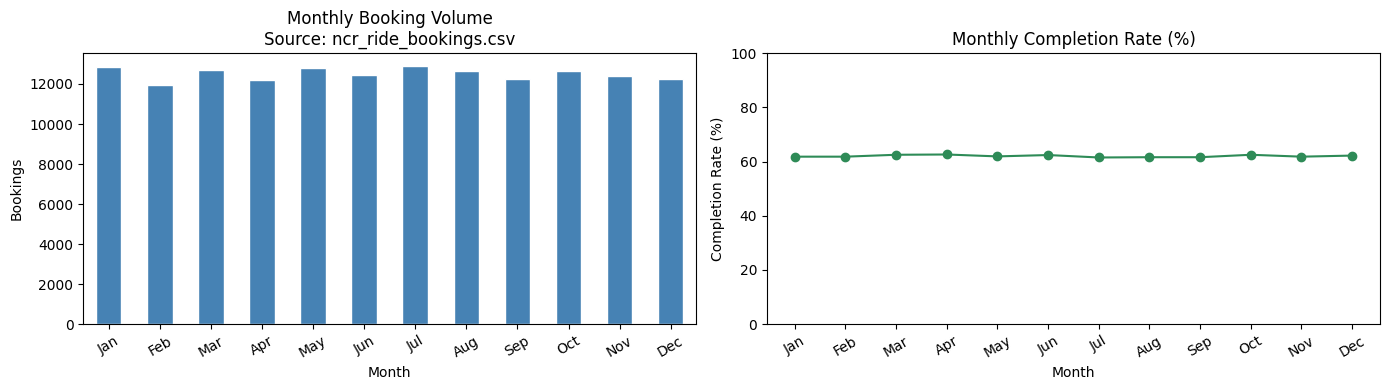

In [5]:
# Monthly booking volume
monthly_vol = df.groupby('month').size().rename('bookings')
monthly_comp = completed.groupby('month').size().rename('completed')
monthly = pd.concat([monthly_vol, monthly_comp], axis=1)
monthly['completion_rate'] = (monthly['completed'] / monthly['bookings'] * 100).round(1)

month_labels = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

ax = axes[0]
monthly['bookings'].plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')
ax.set_title('Monthly Booking Volume\nSource: ncr_ride_bookings.csv')
ax.set_xlabel('Month')
ax.set_ylabel('Bookings')
ax.set_xticklabels(month_labels, rotation=30)

ax = axes[1]
monthly['completion_rate'].plot(kind='line', ax=ax, marker='o', color='seagreen')
ax.set_title('Monthly Completion Rate (%)')
ax.set_xlabel('Month')
ax.set_ylabel('Completion Rate (%)')
ax.set_xticks(range(1, 13))
ax.set_xticklabels(month_labels, rotation=30)
ax.set_ylim(0, 100)

plt.tight_layout()
fig.savefig('outputs/plots/03_monthly_volume.png', dpi=150, bbox_inches='tight')
plt.show()

## 3.2 Booking Status Breakdown by Month

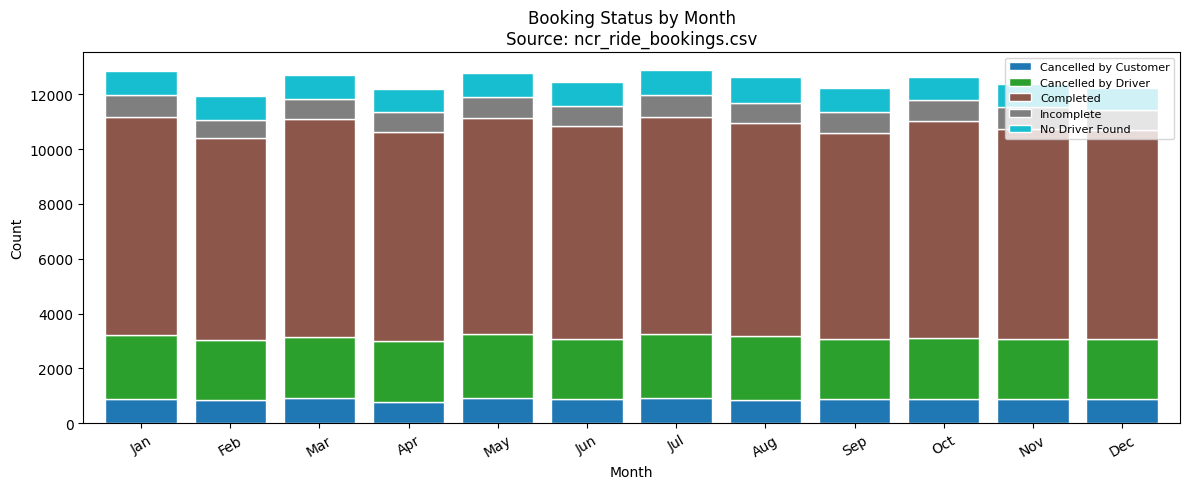

In [6]:
status_month = df.groupby(['month', 'Booking Status'], observed=True).size().unstack(fill_value=0)
status_month.index = month_labels

fig, ax = plt.subplots(figsize=(12, 5))
status_month.plot(kind='bar', stacked=True, ax=ax, colormap='tab10', edgecolor='white', width=0.8)
ax.set_title('Booking Status by Month\nSource: ncr_ride_bookings.csv')
ax.set_xlabel('Month')
ax.set_ylabel('Count')
ax.tick_params(axis='x', rotation=30)
ax.legend(loc='upper right', fontsize=8)
plt.tight_layout()
fig.savefig('outputs/plots/03_status_by_month.png', dpi=150, bbox_inches='tight')
plt.show()

## 3.3 Vehicle Type Analysis

In [7]:
vehicle_stats = df.groupby('Vehicle Type', observed=True).agg(
    total_bookings=('Booking ID', 'count'),
    completed=('is_completed', 'sum'),
    avg_booking_value=('Booking Value', 'mean'),
    avg_ride_distance=('Ride Distance', 'mean'),
    avg_vtat=('Avg VTAT', 'mean'),
).round(2)
vehicle_stats['completion_rate_pct'] = (vehicle_stats['completed'] / vehicle_stats['total_bookings'] * 100).round(1)
vehicle_stats = vehicle_stats.sort_values('total_bookings', ascending=False)
print('Vehicle Type Statistics:')
print(vehicle_stats.to_string())
vehicle_stats.to_csv('outputs/reports/vehicle_stats.csv')

Vehicle Type Statistics:
               total_bookings  completed  avg_booking_value  avg_ride_distance  avg_vtat  completion_rate_pct
Vehicle Type                                                                                                 
Auto                    37419      23155             506.73              24.62      8.45                 61.9
Go Mini                 29806      18549             507.68              24.61      8.47                 62.2
Go Sedan                27141      16676             511.50              24.61      8.40                 61.4
Bike                    22517      14034             510.20              24.65      8.50                 62.3
Premier Sedan           18111      11252             509.57              24.60      8.44                 62.1
eBike                   10557       6551             503.90              24.99      8.48                 62.1
Uber XL                  4449       2783             501.82              24.40      8.58       

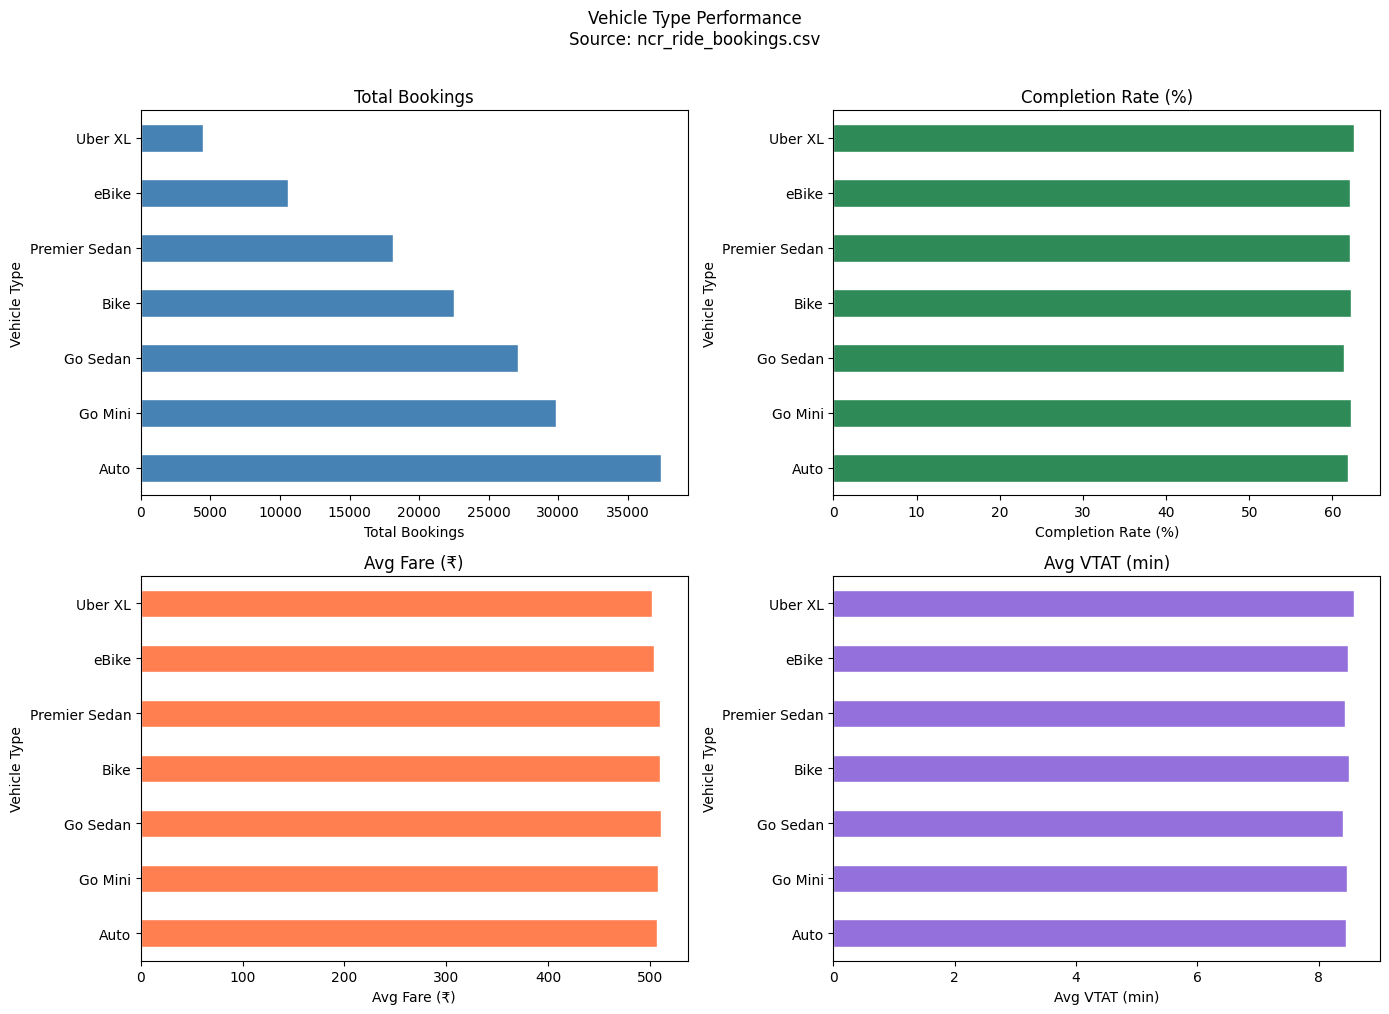

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
metrics = [
    ('total_bookings', 'Total Bookings', 'steelblue'),
    ('completion_rate_pct', 'Completion Rate (%)', 'seagreen'),
    ('avg_booking_value', 'Avg Fare (₹)', 'coral'),
    ('avg_vtat', 'Avg VTAT (min)', 'mediumpurple'),
]
for ax, (col, title, color) in zip(axes.flatten(), metrics):
    vehicle_stats[col].plot(kind='barh', ax=ax, color=color, edgecolor='white')
    ax.set_title(title)
    ax.set_xlabel(title)
fig.suptitle('Vehicle Type Performance\nSource: ncr_ride_bookings.csv', y=1.01)
plt.tight_layout()
fig.savefig('outputs/plots/03_vehicle_performance.png', dpi=150, bbox_inches='tight')
plt.show()

## 3.4 Revenue Overview (Gross Booking Value)

> ⚠️ All revenue figures below are **Gross Booking Value (GBV)** — the fare paid by the customer.  
> Net revenue, driver payout, commission, and margin are **unavailable** (no cost fields in dataset).

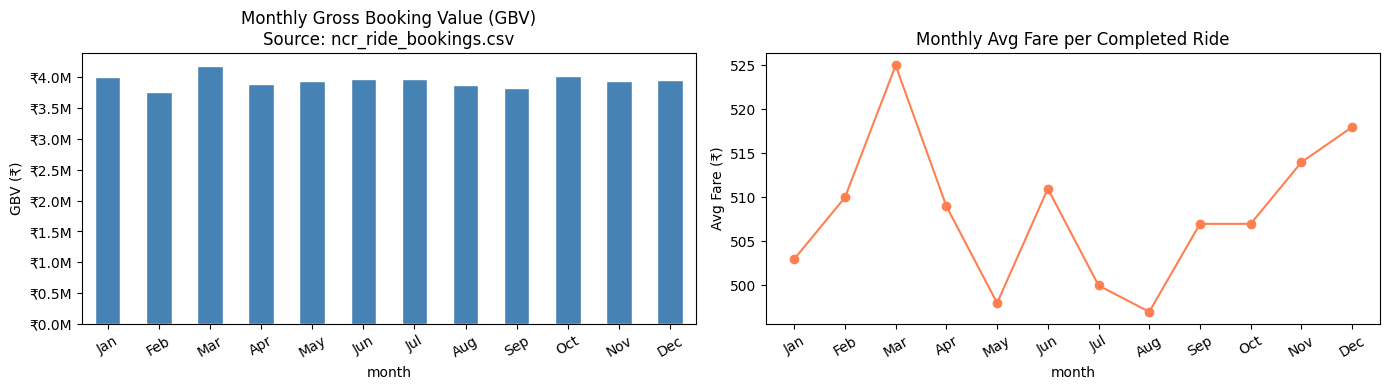

In [9]:
monthly_gbv = completed.groupby('month')['Booking Value'].sum()
monthly_avg_fare = completed.groupby('month')['Booking Value'].mean().round(0)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
ax = axes[0]
monthly_gbv.plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')
ax.set_title('Monthly Gross Booking Value (GBV)\nSource: ncr_ride_bookings.csv')
ax.set_ylabel('GBV (₹)')
ax.set_xticklabels(month_labels, rotation=30)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'₹{x/1e6:.1f}M'))

ax = axes[1]
monthly_avg_fare.plot(kind='line', marker='o', ax=ax, color='coral')
ax.set_title('Monthly Avg Fare per Completed Ride')
ax.set_ylabel('Avg Fare (₹)')
ax.set_xticks(range(1, 13))
ax.set_xticklabels(month_labels, rotation=30)

plt.tight_layout()
fig.savefig('outputs/plots/03_monthly_revenue.png', dpi=150, bbox_inches='tight')
plt.show()

In [10]:
# GBV by vehicle type
gbv_vehicle = completed.groupby('Vehicle Type', observed=True)['Booking Value'].sum().sort_values(ascending=False)
print('GBV by Vehicle Type:')
print(gbv_vehicle.apply(lambda x: f'₹{x:,.0f}').to_string())

# GBV by payment method
gbv_payment = completed.groupby('Payment Method', observed=True)['Booking Value'].sum().sort_values(ascending=False)
print('\nGBV by Payment Method:')
print(gbv_payment.apply(lambda x: f'₹{x:,.0f}').to_string())

GBV by Vehicle Type:
Vehicle Type
Auto             ₹11,727,615
Go Mini           ₹9,411,418
Go Sedan          ₹8,538,560
Bike              ₹7,144,913
Premier Sedan     ₹5,733,655
eBike             ₹3,298,157
Uber XL           ₹1,406,256

GBV by Payment Method:
Payment Method
UPI            ₹21,274,591
Cash           ₹11,756,071
Uber Wallet     ₹5,669,070
Credit Card     ₹4,753,767
Debit Card      ₹3,807,075


## 3.5 Service Quality Overview

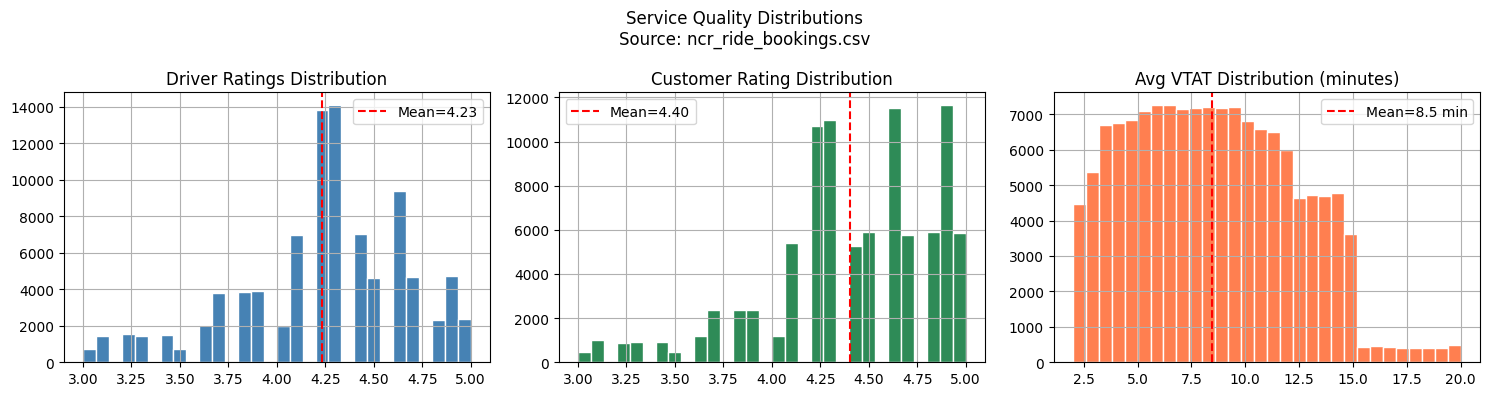

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

ax = axes[0]
completed['Driver Ratings'].dropna().hist(bins=30, ax=ax, color='steelblue', edgecolor='white')
ax.axvline(completed['Driver Ratings'].mean(), color='red', linestyle='--', label=f"Mean={completed['Driver Ratings'].mean():.2f}")
ax.set_title('Driver Ratings Distribution')
ax.legend()

ax = axes[1]
completed['Customer Rating'].dropna().hist(bins=30, ax=ax, color='seagreen', edgecolor='white')
ax.axvline(completed['Customer Rating'].mean(), color='red', linestyle='--', label=f"Mean={completed['Customer Rating'].mean():.2f}")
ax.set_title('Customer Rating Distribution')
ax.legend()

ax = axes[2]
df['Avg VTAT'].dropna().hist(bins=30, ax=ax, color='coral', edgecolor='white')
ax.axvline(df['Avg VTAT'].mean(), color='red', linestyle='--', label=f"Mean={df['Avg VTAT'].mean():.1f} min")
ax.set_title('Avg VTAT Distribution (minutes)')
ax.legend()

fig.suptitle('Service Quality Distributions\nSource: ncr_ride_bookings.csv')
plt.tight_layout()
fig.savefig('outputs/plots/03_service_quality.png', dpi=150, bbox_inches='tight')
plt.show()

## 3.6 Top Locations & Routes

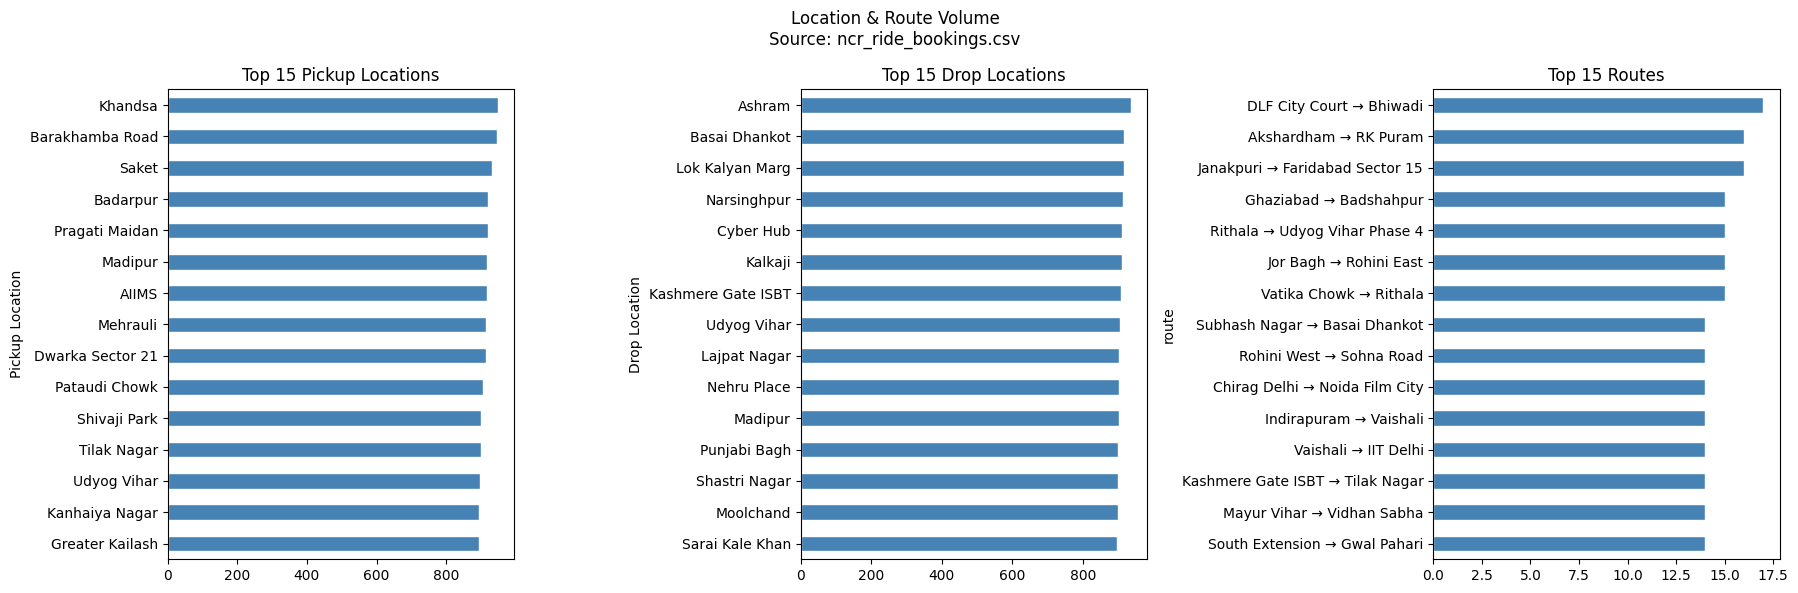

In [12]:
top_pickup = df['Pickup Location'].value_counts().head(15)
top_drop   = df['Drop Location'].value_counts().head(15)
top_routes = df['route'].value_counts().head(15)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for ax, data, title in zip(axes,
    [top_pickup, top_drop, top_routes],
    ['Top 15 Pickup Locations', 'Top 15 Drop Locations', 'Top 15 Routes']):
    data.plot(kind='barh', ax=ax, color='steelblue', edgecolor='white')
    ax.set_title(title)
    ax.invert_yaxis()
fig.suptitle('Location & Route Volume\nSource: ncr_ride_bookings.csv')
plt.tight_layout()
fig.savefig('outputs/plots/03_top_locations.png', dpi=150, bbox_inches='tight')
plt.show()

## 3.7 Payment Method Mix

Payment method distribution (completed rides):
Payment Method
UPI            41834
Cash           23114
Uber Wallet    11206
Credit Card     9320
Debit Card      7526


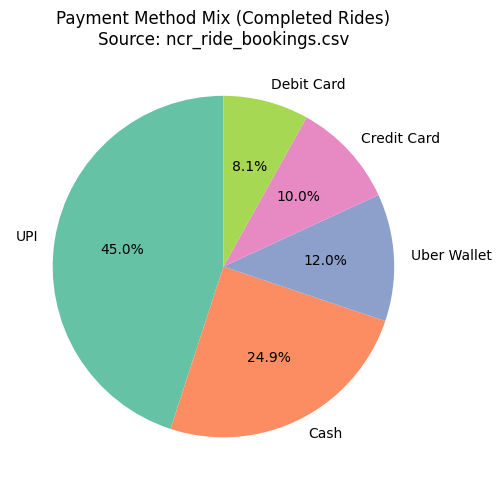

In [13]:
payment_counts = completed['Payment Method'].value_counts()
print('Payment method distribution (completed rides):')
print(payment_counts.to_string())

fig, ax = plt.subplots(figsize=(6, 5))
ax.pie(payment_counts.values, labels=payment_counts.index, autopct='%1.1f%%',
       startangle=90, colors=plt.cm.Set2.colors[:len(payment_counts)])
ax.set_title('Payment Method Mix (Completed Rides)\nSource: ncr_ride_bookings.csv')
plt.tight_layout()
fig.savefig('outputs/plots/03_payment_mix.png', dpi=150, bbox_inches='tight')
plt.show()

## Limitations
- All revenue is GBV only. Net revenue, driver payout, commission, operating cost, and contribution margin cannot be calculated (no cost data in dataset).
- OCV (Observed Customer Value) refers to total fare paid within the observation window — it is not LTV and makes no forward projection.
- CAC, ROAS, and LTV are unavailable.

# Part 4: 04 Diagnostic Analytics

# Notebook 04 — Diagnostic Analytics

**Tier:** 2 — Diagnostic (Why did it happen?)  
**Purpose:** Drill into cancellation causes, No-Driver-Found patterns, incomplete rides,
VTAT/CTAT drivers, rating drivers, and revenue diagnostics.  
**Input:** `outputs/feature_store.parquet`  
**Output:** Charts in `outputs/plots/04_*`, tables in `outputs/reports/`  
**Limitations:** No driver ID → cannot attribute issues to specific drivers.
No cost data → cannot compute net margin or profitability per route.

In [3]:
import os
os.chdir(r"D:\projects\Uber_Data_India_Analytics")
import sys, warnings, pathlib
sys.path.insert(0, '..')
warnings.filterwarnings('ignore')
pathlib.Path('outputs/plots').mkdir(parents=True, exist_ok=True)
pathlib.Path('outputs/reports').mkdir(parents=True, exist_ok=True)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

df = pd.read_parquet('outputs/feature_store.parquet')
completed = df[df['is_completed']].copy()
slot_order = ['Early Morning','Morning','Afternoon','Evening','Night','Late Night']
month_labels = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
print(f'Loaded feature store: {df.shape}  |  completed: {len(completed):,}')

Loaded feature store: (150000, 46)  |  completed: 93,000


## 4.1 Cancellation Deep-Dive

In [4]:
cust_reasons = (df[df['Booking Status'] == 'Cancelled by Customer']
                ['Reason for cancelling by Customer'].value_counts())
drv_reasons  = (df[df['Booking Status'] == 'Cancelled by Driver']
                ['Driver Cancellation Reason'].value_counts())
print('Customer Cancellation Reasons:'); print(cust_reasons.to_string())
print(); print('Driver Cancellation Reasons:');  print(drv_reasons.to_string())

Customer Cancellation Reasons:
Reason for cancelling by Customer
Wrong Address                                   2362
Change of plans                                 2353
Driver is not moving towards pickup location    2335
Driver asked to cancel                          2295
AC is not working                               1155

Driver Cancellation Reasons:
Driver Cancellation Reason
Customer related issue                 6837
The customer was coughing/sick         6751
Personal & Car related issues          6726
More than permitted people in there    6686


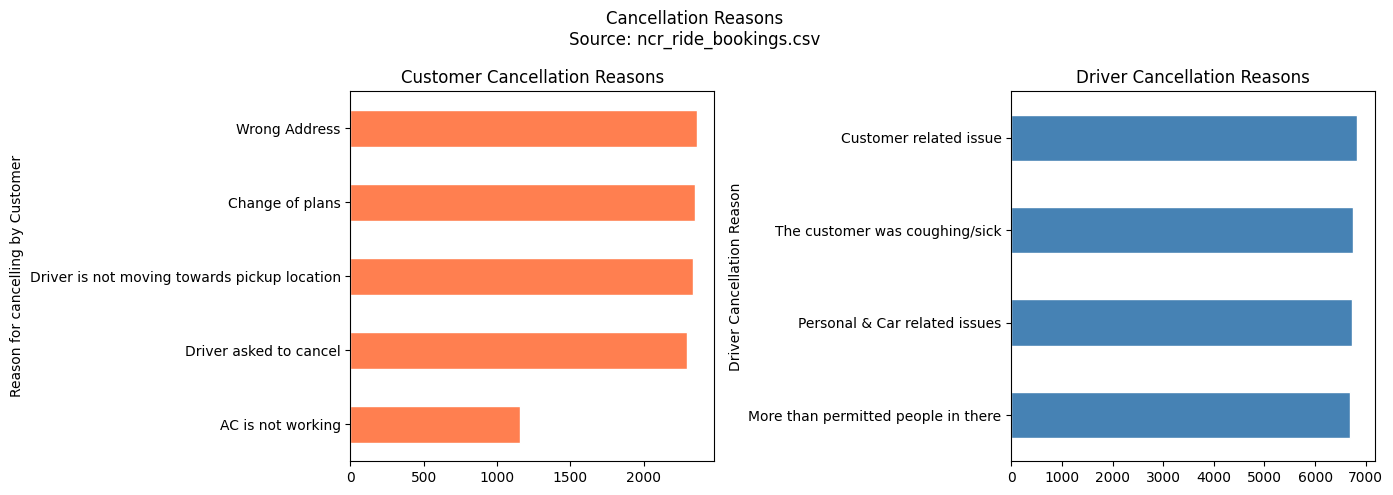

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
cust_reasons.plot(kind='barh', ax=axes[0], color='coral', edgecolor='white')
axes[0].set_title('Customer Cancellation Reasons'); axes[0].invert_yaxis()
drv_reasons.plot(kind='barh', ax=axes[1], color='steelblue', edgecolor='white')
axes[1].set_title('Driver Cancellation Reasons'); axes[1].invert_yaxis()
fig.suptitle('Cancellation Reasons\nSource: ncr_ride_bookings.csv')
plt.tight_layout()
fig.savefig('outputs/plots/04_cancellation_reasons.png', dpi=150, bbox_inches='tight')
plt.show()

In [6]:
# Cancellation rate by vehicle type
canc_by_veh = (df.groupby('Vehicle Type', observed=True)
               .apply(lambda g: g['is_cancelled'].sum() / len(g) * 100)
               .rename('canc_rate_pct').sort_values(ascending=False))
print('Cancellation rate by Vehicle Type (%):', canc_by_veh.round(1).to_string(), sep='\n')

# Cancellation rate by time slot
canc_by_slot = (df.groupby('time_slot', observed=True)
                .apply(lambda g: g['is_cancelled'].sum() / len(g) * 100)
                .rename('canc_rate_pct')
                .reindex([s for s in slot_order if s in df['time_slot'].cat.categories]))
print(); print('Cancellation rate by Time Slot (%):', canc_by_slot.round(1).to_string(), sep='\n')

# Cancellation rate by day of week
canc_by_dow = (df.groupby('day_name')
               .apply(lambda g: g['is_cancelled'].sum() / len(g) * 100)
               .rename('canc_rate_pct')
               .reindex(['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']))
print(); print('Cancellation rate by Day of Week (%):', canc_by_dow.round(1).to_string(), sep='\n')

Cancellation rate by Vehicle Type (%):
Vehicle Type
Go Sedan         25.3
Bike             25.1
Premier Sedan    24.9
Go Mini          24.9
Auto             24.9
eBike            24.9
Uber XL          24.5

Cancellation rate by Time Slot (%):
time_slot
Early Morning    25.2
Morning          24.9
Afternoon        25.0
Evening          25.2
Night            24.6
Late Night       25.4

Cancellation rate by Day of Week (%):
day_name
Monday       25.7
Tuesday      25.2
Wednesday    24.8
Thursday     24.7
Friday       25.0
Saturday     24.7
Sunday       25.0


Customer cancellation rate by VTAT quartile:
vtat_q
Q1 (Low)      0.74
Q2            5.92
Q3            5.99
Q4 (High)    17.73


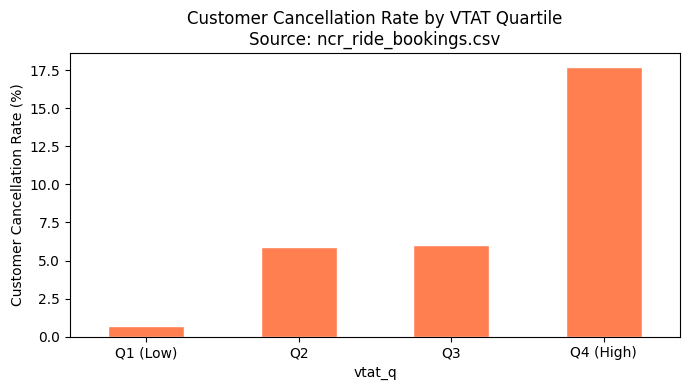

In [7]:
# VTAT quartile → customer cancellation rate
dispatched = df[df['Avg VTAT'].notna()].copy()
dispatched['vtat_q'] = pd.qcut(dispatched['Avg VTAT'], q=4,
                                labels=['Q1 (Low)','Q2','Q3','Q4 (High)'])
vtat_canc = (dispatched.groupby('vtat_q', observed=True)
             .apply(lambda g: (g['Booking Status'] == 'Cancelled by Customer').sum() / len(g) * 100)
             .rename('cust_canc_pct'))
print('Customer cancellation rate by VTAT quartile:', vtat_canc.round(2).to_string(), sep='\n')

fig, ax = plt.subplots(figsize=(7, 4))
vtat_canc.plot(kind='bar', ax=ax, color='coral', edgecolor='white')
ax.set_title('Customer Cancellation Rate by VTAT Quartile\nSource: ncr_ride_bookings.csv')
ax.set_ylabel('Customer Cancellation Rate (%)'); ax.tick_params(axis='x', rotation=0)
plt.tight_layout()
fig.savefig('outputs/plots/04_vtat_canc_rate.png', dpi=150, bbox_inches='tight')
plt.show()

## 4.2 No Driver Found Deep-Dive

In [8]:
ndf_by_veh = (df.groupby('Vehicle Type', observed=True)
              .apply(lambda g: (g['Booking Status'] == 'No Driver Found').sum() / len(g) * 100)
              .rename('ndf_rate_pct').sort_values(ascending=False))
print('No Driver Found rate by Vehicle Type (%):', ndf_by_veh.round(1).to_string(), sep='\n')

ndf_by_slot = (df.groupby('time_slot', observed=True)
               .apply(lambda g: (g['Booking Status'] == 'No Driver Found').sum() / len(g) * 100)
               .rename('ndf_rate_pct')
               .reindex([s for s in slot_order if s in df['time_slot'].cat.categories]))
print(); print('No Driver Found rate by Time Slot (%):', ndf_by_slot.round(1).to_string(), sep='\n')

ndf_monthly = (df.groupby('month')
               .apply(lambda g: (g['Booking Status'] == 'No Driver Found').sum() / len(g) * 100)
               .rename('ndf_rate_pct'))
print(); print('No Driver Found rate by Month (%):', ndf_monthly.round(1).to_string(), sep='\n')

ndf_by_zone = (df.groupby('pickup_zone')
               .apply(lambda g: (g['Booking Status'] == 'No Driver Found').sum() / len(g) * 100)
               .rename('ndf_rate_pct').sort_values(ascending=False))
print(); print('No Driver Found rate by Pickup Zone (%):', ndf_by_zone.round(1).to_string(), sep='\n')

No Driver Found rate by Vehicle Type (%):
Vehicle Type
Go Sedan         7.2
Auto             7.2
Uber XL          7.1
Premier Sedan    7.1
eBike            7.1
Go Mini          6.8
Bike             6.7

No Driver Found rate by Time Slot (%):
time_slot
Early Morning    7.2
Morning          7.0
Afternoon        7.1
Evening          7.0
Night            7.0
Late Night       6.4

No Driver Found rate by Month (%):
month
1     6.9
2     7.1
3     7.0
4     6.9
5     6.8
6     6.9
7     7.0
8     7.4
9     7.4
10    6.9
11    6.9
12    6.8

No Driver Found rate by Pickup Zone (%):
pickup_zone
Faridabad             7.9
Outer NCR             7.3
Gurgaon               7.1
Delhi Core            7.1
Delhi North           7.1
Noida                 7.0
Delhi East            6.9
Gurgaon Peripheral    6.9
Delhi South           6.9
Delhi West            6.8


## 4.3 Incomplete Rides

In [9]:
inc = df[df['Booking Status'] == 'Incomplete']
print('Incomplete Ride Reasons:', inc['Incomplete Rides Reason'].value_counts().to_string(), sep='\n')

inc_by_veh = (df.groupby('Vehicle Type', observed=True)
              .apply(lambda g: (g['Booking Status'] == 'Incomplete').sum() / len(g) * 100)
              .rename('inc_rate_pct').sort_values(ascending=False))
print(); print('Incomplete rate by Vehicle Type (%):', inc_by_veh.round(1).to_string(), sep='\n')

inc_by_slot = (df.groupby('time_slot', observed=True)
               .apply(lambda g: (g['Booking Status'] == 'Incomplete').sum() / len(g) * 100)
               .rename('inc_rate_pct')
               .reindex([s for s in slot_order if s in df['time_slot'].cat.categories]))
print(); print('Incomplete rate by Time Slot (%):', inc_by_slot.round(1).to_string(), sep='\n')

Incomplete Ride Reasons:
Incomplete Rides Reason
Customer Demand      3040
Vehicle Breakdown    3012
Other Issue          2948

Incomplete rate by Vehicle Type (%):
Vehicle Type
Go Mini          6.1
Go Sedan         6.0
Auto             6.0
eBike            6.0
Bike             5.9
Uber XL          5.9
Premier Sedan    5.9

Incomplete rate by Time Slot (%):
time_slot
Early Morning    5.5
Morning          6.0
Afternoon        6.0
Evening          6.1
Night            6.0
Late Night       5.8


## 4.4 VTAT / CTAT Drivers

Avg VTAT by Vehicle (min):
Vehicle Type
Uber XL          8.58
Bike             8.50
eBike            8.48
Go Mini          8.47
Auto             8.45
Premier Sedan    8.44
Go Sedan         8.40

Avg CTAT by Vehicle (min):
Vehicle Type
Premier Sedan    29.22
Uber XL          29.21
Bike             29.20
eBike            29.18
Go Mini          29.16
Auto             29.14
Go Sedan         29.04

Avg VTAT by Time Slot (min):
time_slot
Early Morning    8.45
Morning          8.48
Afternoon        8.47
Evening          8.45
Night            8.43
Late Night       8.46


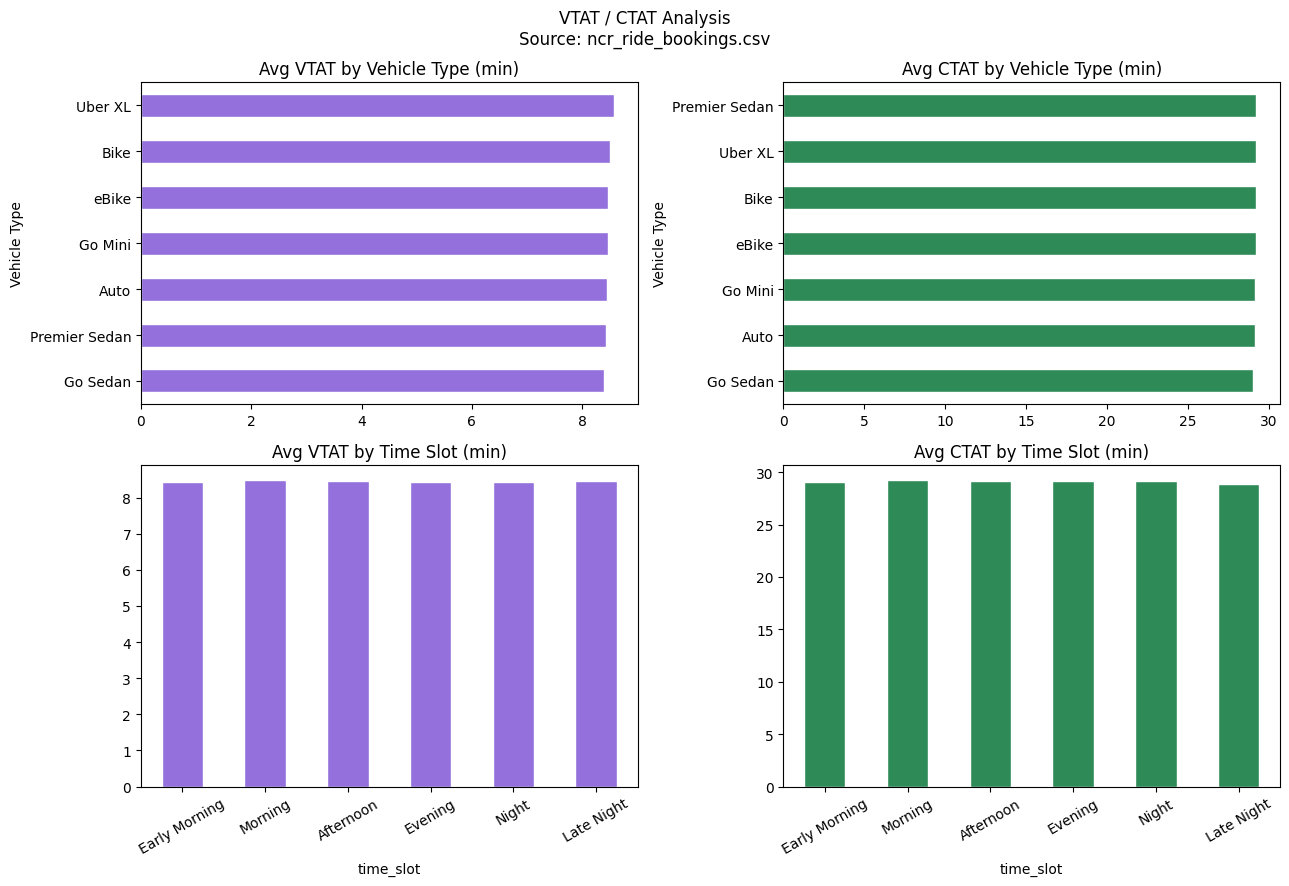

In [10]:
vtat_veh = df.groupby('Vehicle Type', observed=True)['Avg VTAT'].mean().sort_values(ascending=False)
ctat_veh = df.groupby('Vehicle Type', observed=True)['Avg CTAT'].mean().sort_values(ascending=False)
vtat_slot = (df.groupby('time_slot', observed=True)['Avg VTAT'].mean()
               .reindex([s for s in slot_order if s in df['time_slot'].cat.categories]))
ctat_slot = (df.groupby('time_slot', observed=True)['Avg CTAT'].mean()
               .reindex([s for s in slot_order if s in df['time_slot'].cat.categories]))

print('Avg VTAT by Vehicle (min):'); print(vtat_veh.round(2).to_string())
print(); print('Avg CTAT by Vehicle (min):'); print(ctat_veh.round(2).to_string())
print(); print('Avg VTAT by Time Slot (min):'); print(vtat_slot.round(2).to_string())

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
vtat_veh.plot(kind='barh', ax=axes[0,0], color='mediumpurple', edgecolor='white')
axes[0,0].set_title('Avg VTAT by Vehicle Type (min)'); axes[0,0].invert_yaxis()
ctat_veh.plot(kind='barh', ax=axes[0,1], color='seagreen', edgecolor='white')
axes[0,1].set_title('Avg CTAT by Vehicle Type (min)'); axes[0,1].invert_yaxis()
vtat_slot.plot(kind='bar', ax=axes[1,0], color='mediumpurple', edgecolor='white')
axes[1,0].set_title('Avg VTAT by Time Slot (min)'); axes[1,0].tick_params(axis='x', rotation=30)
ctat_slot.plot(kind='bar', ax=axes[1,1], color='seagreen', edgecolor='white')
axes[1,1].set_title('Avg CTAT by Time Slot (min)'); axes[1,1].tick_params(axis='x', rotation=30)
fig.suptitle('VTAT / CTAT Analysis\nSource: ncr_ride_bookings.csv')
plt.tight_layout()
fig.savefig('outputs/plots/04_vtat_ctat.png', dpi=150, bbox_inches='tight')
plt.show()

## 4.5 Rating Drivers

In [11]:
low_dr = completed[completed['Driver Ratings'] < 4.0]
print(f'Low-rated rides (Driver Rating < 4.0): {len(low_dr):,}  '
      f'({len(low_dr)/len(completed)*100:.1f}% of completed)')
print('By Vehicle Type:', low_dr.groupby('Vehicle Type', observed=True).size()
      .sort_values(ascending=False).to_string(), sep='\n')

corr_bv_dr  = completed[['Booking Value','Driver Ratings']].corr().iloc[0,1]
vtat_cr_sub = df[df['Avg VTAT'].notna() & df['Customer Rating'].notna()]
corr_vtat_cr = vtat_cr_sub[['Avg VTAT','Customer Rating']].corr().iloc[0,1]
corr_dist_cr = completed[['Ride Distance','Customer Rating']].corr().iloc[0,1]
print(f'\nCorr(Booking Value, Driver Rating)  : {corr_bv_dr:.4f}')
print(f'Corr(Avg VTAT, Customer Rating)     : {corr_vtat_cr:.4f}')
print(f'Corr(Ride Distance, Customer Rating): {corr_dist_cr:.4f}')

Low-rated rides (Driver Rating < 4.0): 21,021  (22.6% of completed)
By Vehicle Type:
Vehicle Type
Auto             5188
Go Mini          4261
Go Sedan         3762
Bike             3195
Premier Sedan    2504
eBike            1500
Uber XL           611

Corr(Booking Value, Driver Rating)  : -0.0002
Corr(Avg VTAT, Customer Rating)     : -0.0039
Corr(Ride Distance, Customer Rating): 0.0045


## 4.6 Revenue Diagnostics

In [12]:
fare_per_km_veh = completed.groupby('Vehicle Type', observed=True)['fare_per_km'].mean().sort_values(ascending=False)
print('Avg Fare/km by Vehicle Type (₹/km):', fare_per_km_veh.round(2).to_string(), sep='\n')

monthly_avg_fare = completed.groupby('month')['Booking Value'].mean().round(0)
print(); print('Monthly Avg Fare (₹):', monthly_avg_fare.to_string(), sep='\n')

route_gbv = completed.groupby('route')['Booking Value'].sum().sort_values(ascending=False)
top10p = route_gbv.head(max(1, len(route_gbv) // 10))
total_gbv = completed['Booking Value'].sum()
print(f'\nTop 10% of routes account for {top10p.sum()/total_gbv*100:.1f}% of total GBV')
print('Top 10 routes by GBV:'); print(route_gbv.head(10).apply(lambda x: f'₹{x:,.0f}').to_string())

# Save diagnostic table
diag = pd.DataFrame({
    'canc_rate_pct': canc_by_veh,
    'ndf_rate_pct': ndf_by_veh,
    'inc_rate_pct': inc_by_veh,
    'avg_vtat_min': vtat_veh,
    'avg_ctat_min': ctat_veh,
    'avg_fare_per_km': fare_per_km_veh,
})
diag.to_csv('outputs/reports/vehicle_diagnostics.csv')
print('\nSaved: outputs/reports/vehicle_diagnostics.csv')

Avg Fare/km by Vehicle Type (₹/km):
Vehicle Type
Go Sedan         34.66
Auto             34.00
Bike             33.89
Uber XL          33.85
Premier Sedan    33.73
Go Mini          33.49
eBike            32.47

Monthly Avg Fare (₹):
month
1     503.0
2     510.0
3     525.0
4     509.0
5     498.0
6     511.0
7     500.0
8     497.0
9     507.0
10    507.0
11    514.0
12    518.0

Top 10% of routes account for 24.5% of total GBV
Top 10 routes by GBV:
route
Nirman Vihar → Vatika Chowk            ₹9,284
Ashok Vihar → Basai Dhankot            ₹9,280
Anand Vihar ISBT → Noida Film City     ₹8,960
Ambience Mall → Akshardham             ₹8,518
Cyber Hub → Gurgaon Railway Station    ₹8,396
Greater Noida → Jor Bagh               ₹8,252
Noida Extension → Vaishali             ₹8,202
Greater Noida → Rithala                ₹8,082
Udyog Vihar → Tagore Garden            ₹7,940
Cyber Hub → Chanakyapuri               ₹7,900

Saved: outputs/reports/vehicle_diagnostics.csv


## Limitations
- No driver ID — cannot attribute cancellations, low ratings, or VTAT issues to individual drivers.
- Driver payout, commission, operating cost are unavailable — net profitability per vehicle/route cannot be calculated.
- CAC, LTV, ROAS are unavailable (no cost or acquisition channel data).

# Part 5: 05 Customer Segmentation

# Notebook 05 — Customer Segmentation

**Tier:** 2 / 3 — Diagnostic & Predictive  
**Purpose:** RFM scoring, K-Means clustering, repeat-customer analysis.  
**Input:** `outputs/feature_store.parquet`  
**Output:** `outputs/reports/rfm_segments.csv`, `outputs/reports/cluster_profiles.csv`, charts  

> **Important caveat:** 148,788 unique Customer IDs across 150,000 bookings.
> Most customers appear only once — RFM and clusters reflect this reality.
> Per-customer cumulative revenue is reported as **OCV (Observed Customer Value)** — NOT LTV.
> Net revenue, driver payout, and margin are unavailable.

In [2]:
import os
os.chdir(r"D:\projects\Uber_Data_India_Analytics")
import sys, warnings, pathlib
sys.path.insert(0, '..')
warnings.filterwarnings('ignore')
pathlib.Path('outputs/plots').mkdir(parents=True, exist_ok=True)
pathlib.Path('outputs/reports').mkdir(parents=True, exist_ok=True)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

df = pd.read_parquet('outputs/feature_store.parquet')
completed = df[df['is_completed']].copy()
slot_order = ['Early Morning','Morning','Afternoon','Evening','Night','Late Night']
month_labels = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
print(f'Loaded feature store: {df.shape}  |  completed: {len(completed):,}')

Loaded feature store: (150000, 46)  |  completed: 93,000


## 5.1 Repeat Customer Analysis

In [3]:
rides_per_cust = df.groupby('Customer ID').size()
one_ride   = (rides_per_cust == 1).sum()
two_rides  = (rides_per_cust == 2).sum()
three_plus = (rides_per_cust >= 3).sum()
total_custs = rides_per_cust.nunique() if hasattr(rides_per_cust, 'nunique') else len(rides_per_cust)

print(f'Unique customers       : {len(rides_per_cust):,}')
print(f'  1 ride               : {one_ride:,}  ({one_ride/len(rides_per_cust)*100:.1f}%)')
print(f'  2 rides              : {two_rides:,}  ({two_rides/len(rides_per_cust)*100:.1f}%)')
print(f'  3+ rides             : {three_plus:,}  ({three_plus/len(rides_per_cust)*100:.1f}%)')

repeat_ids = rides_per_cust[rides_per_cust > 1].index
repeat_mask = df['Customer ID'].isin(repeat_ids)
print(f'\nCompletion rate — one-time : {df[~repeat_mask]["is_completed"].mean()*100:.1f}%')
print(f'Completion rate — repeat   : {df[repeat_mask]["is_completed"].mean()*100:.1f}%')

Unique customers       : 148,788
  1 ride               : 147,582  (99.2%)
  2 rides              : 1,200  (0.8%)
  3+ rides             : 6  (0.0%)

Completion rate — one-time : 62.0%
Completion rate — repeat   : 61.4%


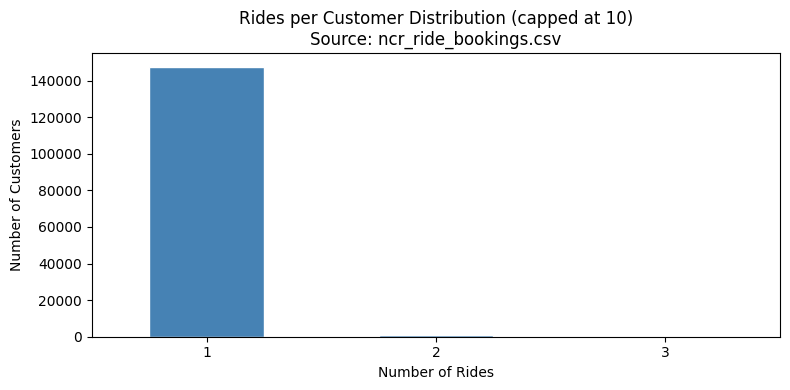

In [4]:
fig, ax = plt.subplots(figsize=(8, 4))
rides_per_cust.clip(upper=10).value_counts().sort_index().plot(
    kind='bar', ax=ax, color='steelblue', edgecolor='white')
ax.set_title('Rides per Customer Distribution (capped at 10)\nSource: ncr_ride_bookings.csv')
ax.set_xlabel('Number of Rides'); ax.set_ylabel('Number of Customers')
ax.tick_params(axis='x', rotation=0)
plt.tight_layout()
fig.savefig('outputs/plots/05_rides_per_customer.png', dpi=150, bbox_inches='tight')
plt.show()

In [5]:
# Observed Customer Value (OCV) — NOT LTV
cust_ocv_repeat   = completed[completed['Customer ID'].isin(repeat_ids)].groupby('Customer ID')['Booking Value'].sum()
cust_ocv_onetime  = completed[~completed['Customer ID'].isin(repeat_ids)].groupby('Customer ID')['Booking Value'].sum()
print(f'Avg OCV — one-time customers : ₹{cust_ocv_onetime.mean():.0f}')
print(f'Avg OCV — repeat customers   : ₹{cust_ocv_repeat.mean():.0f}')
print()
print('Note: OCV = sum of Booking Value on completed rides within observation window.')
print('      It is NOT LTV; it makes no forward projection and no claim about profitability.')

Avg OCV — one-time customers : ₹508
Avg OCV — repeat customers   : ₹721

Note: OCV = sum of Booking Value on completed rides within observation window.
      It is NOT LTV; it makes no forward projection and no claim about profitability.


## 5.2 RFM Scoring

In [6]:
from src.segmentation import build_rfm

rfm = build_rfm(df)
print(f'RFM table shape: {rfm.shape}')
print(rfm.head())

RFM table shape: (148788, 9)
  Customer ID  recency_days  frequency  monetary_ocv  R  F  M rfm_score  \
0  CID1000119           287          1           0.0  1  1  1       111   
1  CID1000157           178          1           0.0  3  1  1       311   
2  CID1000234            95          1         458.0  3  1  3       313   
3  CID1000323           283          1        1498.0  1  1  4       114   
4  CID1000434             2          1           0.0  4  1  1       411   

          rfm_segment  
0                Lost  
1  Potential Loyalist  
2  Potential Loyalist  
3                Lost  
4  Potential Loyalist  


RFM Segment Sizes:
rfm_segment
Potential Loyalist    37182
Lost                  36974
Loyal                 35486
At Risk               27711
Hibernating            9306
Champion               2129

Saved: outputs/reports/rfm_segments.csv


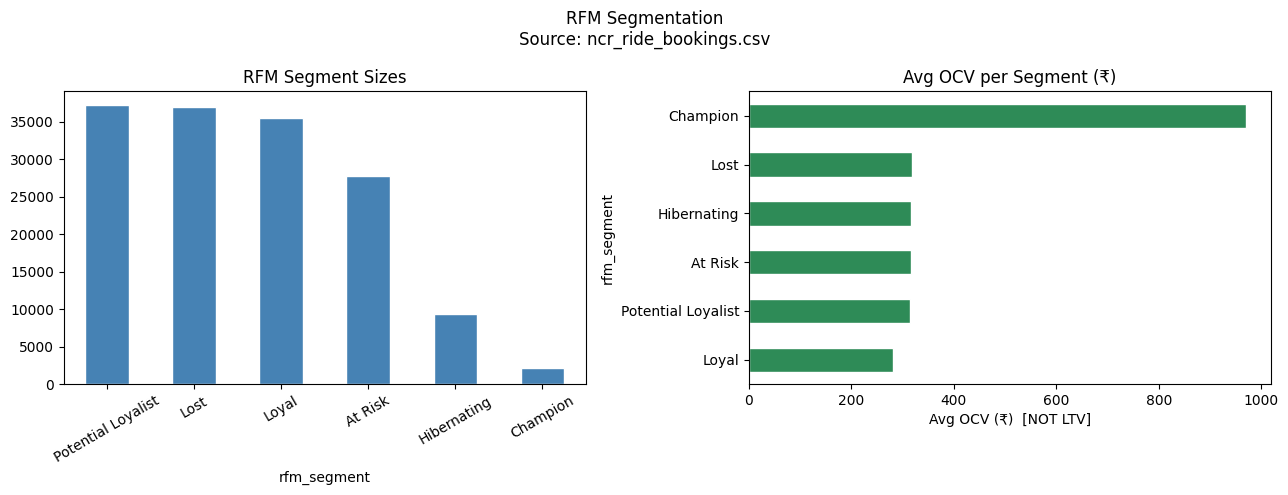

In [7]:
seg_counts = rfm['rfm_segment'].value_counts()
print('RFM Segment Sizes:'); print(seg_counts.to_string())
rfm.to_csv('outputs/reports/rfm_segments.csv', index=False)
print('\nSaved: outputs/reports/rfm_segments.csv')

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
seg_counts.plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('RFM Segment Sizes'); axes[0].tick_params(axis='x', rotation=30)

rfm.groupby('rfm_segment')['monetary_ocv'].mean().sort_values().plot(
    kind='barh', ax=axes[1], color='seagreen', edgecolor='white')
axes[1].set_title('Avg OCV per Segment (₹)')
axes[1].set_xlabel('Avg OCV (₹)  [NOT LTV]')
fig.suptitle('RFM Segmentation\nSource: ncr_ride_bookings.csv')
plt.tight_layout()
fig.savefig('outputs/plots/05_rfm_segments.png', dpi=150, bbox_inches='tight')
plt.show()

## 5.3 K-Means Clustering

In [8]:
from src.segmentation import build_cluster_features, run_kmeans, pca_2d
import numpy as np
from sklearn.preprocessing import StandardScaler

feat_df = build_cluster_features(df)
print(f'Cluster feature matrix: {feat_df.shape}')
print(feat_df.head(3))

NameError: name 'avg_driver_rating_given' is not defined

In [ ]:
best_model, labels, scaler, elbow_df = run_kmeans(feat_df, k_range=range(2, 8))
print(elbow_df.to_string(index=False))
best_k = int(elbow_df.loc[elbow_df['silhouette'].idxmax(), 'k'])
print(f'\nSelected k = {best_k}  (highest silhouette score)')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
elbow_df.plot(x='k', y='inertia', marker='o', ax=axes[0], legend=False, color='steelblue')
axes[0].set_title('Elbow Plot (Inertia)'); axes[0].set_xlabel('k')
elbow_df.plot(x='k', y='silhouette', marker='o', ax=axes[1], legend=False, color='seagreen')
axes[1].set_title('Silhouette Score'); axes[1].set_xlabel('k')
plt.tight_layout()
fig.savefig('outputs/plots/05_kmeans_selection.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
feat_df = feat_df.copy()
feat_df['cluster'] = labels

numeric_cols = feat_df.select_dtypes(include='number').columns.drop('cluster').tolist()
X_scaled = scaler.transform(feat_df[numeric_cols].fillna(0))
coords = pca_2d(X_scaled)

fig, ax = plt.subplots(figsize=(8, 6))
for cl in sorted(feat_df['cluster'].unique()):
    mask = feat_df['cluster'] == cl
    ax.scatter(coords[mask, 0], coords[mask, 1], label=f'Cluster {cl}', alpha=0.5, s=8)
ax.set_title(f'Customer Clusters (PCA 2D, k={best_k})\nSource: ncr_ride_bookings.csv')
ax.set_xlabel('PC1'); ax.set_ylabel('PC2'); ax.legend()
plt.tight_layout()
fig.savefig('outputs/plots/05_clusters_pca.png', dpi=150, bbox_inches='tight')
plt.show()

## 5.4 Cluster Profiles

In [ ]:
profile = feat_df.groupby('cluster')[numeric_cols].mean().round(2)
print('Cluster profiles (mean features):')
print(profile.T.to_string())
profile.to_csv('outputs/reports/cluster_profiles.csv')
print('\nSaved: outputs/reports/cluster_profiles.csv')

## Limitations
- OCV is reported as a proxy for customer value. It is **not** LTV — no forward projection, no cost deduction.
- CAC, ROAS, driver payout, commission, operating cost, and contribution margin are all **unavailable** (no cost fields).
- Most customers appear only once in 2024; clustering is driven primarily by single-trip behaviour.

# Part 6: 06 Cohort Retention

# Notebook 06 — Cohort & Retention Analysis

**Tier:** 2 — Diagnostic  
**Purpose:** Track whether customers acquired in earlier months return.  
**Input:** `outputs/feature_store.parquet`  
**Output:** `outputs/reports/cohort_retention_rate.csv`, `outputs/reports/cohort_gbv.csv`, charts  

> **Documented caveat:** With ~148,788 unique customers across 150,000 bookings, the
> vast majority appear only once. True month-over-month retention will be very low.
> This is real signal — high single-use / low-return behaviour — reported as a key finding.
> All revenue figures are **Gross Booking Value (GBV)** — not net revenue.

In [1]:
import os
os.chdir(r"D:\projects\Uber_Data_India_Analytics")
import sys, warnings, pathlib
sys.path.insert(0, '..')
warnings.filterwarnings('ignore')
pathlib.Path('outputs/plots').mkdir(parents=True, exist_ok=True)
pathlib.Path('outputs/reports').mkdir(parents=True, exist_ok=True)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

df = pd.read_parquet('outputs/feature_store.parquet')
completed = df[df['is_completed']].copy()
slot_order = ['Early Morning','Morning','Afternoon','Evening','Night','Late Night']
month_labels = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
print(f'Loaded feature store: {df.shape}  |  completed: {len(completed):,}')

Loaded feature store: (150000, 46)  |  completed: 93,000


## 6.1 Cohort Construction

In [2]:
from src.cohort import (build_cohort_retention, build_cohort_retention_rate,
                        build_cohort_revenue, avg_retention_curve)

count_matrix = build_cohort_retention(df)
print(f'Cohort count matrix shape: {count_matrix.shape}')
print('Cohort sizes (month 0):')
print(count_matrix[0].to_string())

Cohort count matrix shape: (12, 12)
Cohort sizes (month 0):
cohort_month
2024-01    12858.0
2024-02    11895.0
2024-03    12682.0
2024-04    12129.0
2024-05    12706.0
2024-06    12351.0
2024-07    12795.0
2024-08    12510.0
2024-09    12085.0
2024-10    12498.0
2024-11    12222.0
2024-12    12057.0


## 6.2 Retention Rate Matrix

In [3]:
rate_matrix = build_cohort_retention_rate(count_matrix)
print('Cohort Retention Rate Matrix (%):', )
print(rate_matrix.to_string())
rate_matrix.to_csv('outputs/reports/cohort_retention_rate.csv')
print('\nSaved: outputs/reports/cohort_retention_rate.csv')

Cohort Retention Rate Matrix (%):
                 0    1    2    3    4    5    6    7    8    9    10   11
cohort_month                                                              
2024-01       100.0  0.2  0.1  0.2  0.1  0.1  0.2  0.1  0.1  0.1  0.2  0.1
2024-02       100.0  0.1  0.2  0.0  0.1  0.1  0.1  0.2  0.1  0.2  0.2  NaN
2024-03       100.0  0.1  0.2  0.1  0.1  0.2  0.2  0.1  0.1  0.2  NaN  NaN
2024-04       100.0  0.1  0.2  0.1  0.2  0.2  0.1  0.1  0.1  NaN  NaN  NaN
2024-05       100.0  0.1  0.1  0.1  0.1  0.1  0.2  0.1  NaN  NaN  NaN  NaN
2024-06       100.0  0.1  0.2  0.1  0.2  0.2  0.1  NaN  NaN  NaN  NaN  NaN
2024-07       100.0  0.1  0.2  0.1  0.1  0.1  NaN  NaN  NaN  NaN  NaN  NaN
2024-08       100.0  0.1  0.1  0.1  0.2  NaN  NaN  NaN  NaN  NaN  NaN  NaN
2024-09       100.0  0.1  0.1  0.1  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN
2024-10       100.0  0.1  0.1  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN
2024-11       100.0  0.1  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  

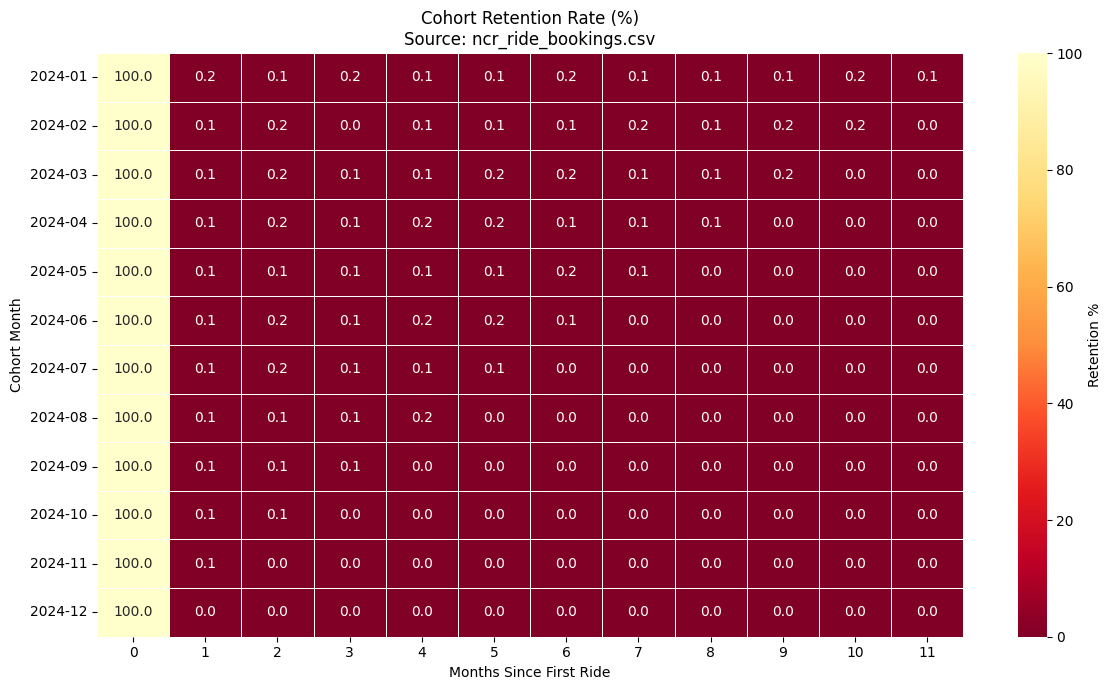

In [4]:
fig, ax = plt.subplots(figsize=(12, 7))
# Only plot columns up to the max available
cols_to_plot = [c for c in sorted(rate_matrix.columns) if c <= 11]
plot_data = rate_matrix[cols_to_plot].fillna(0)
sns.heatmap(plot_data, annot=True, fmt='.1f', cmap='YlOrRd_r',
            linewidths=0.4, ax=ax, cbar_kws={'label': 'Retention %'})
ax.set_title('Cohort Retention Rate (%)\nSource: ncr_ride_bookings.csv')
ax.set_xlabel('Months Since First Ride'); ax.set_ylabel('Cohort Month')
plt.tight_layout()
fig.savefig('outputs/plots/06_cohort_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

Average Retention Curve (%):
0     100.0
1       0.1
2       0.2
3       0.1
4       0.1
5       0.1
6       0.2
7       0.1
8       0.1
9       0.2
10      0.2
11      0.1


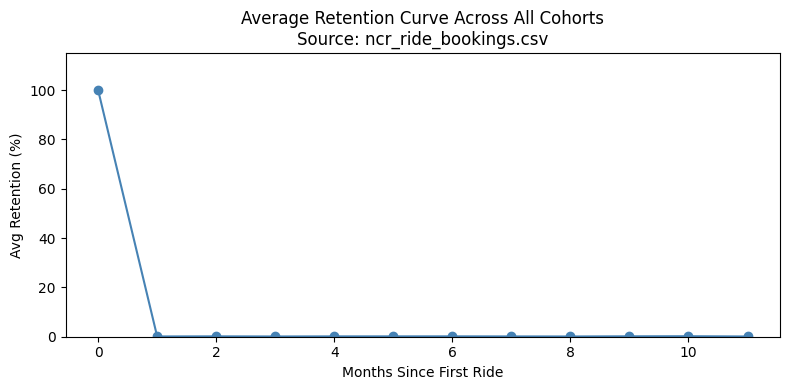

In [5]:
curve = avg_retention_curve(rate_matrix)
print('Average Retention Curve (%):', curve.round(1).to_string(), sep='\n')

fig, ax = plt.subplots(figsize=(8, 4))
curve.plot(kind='line', marker='o', ax=ax, color='steelblue')
ax.set_title('Average Retention Curve Across All Cohorts\nSource: ncr_ride_bookings.csv')
ax.set_xlabel('Months Since First Ride'); ax.set_ylabel('Avg Retention (%)')
ax.set_ylim(0, max(curve.max() * 1.15, 10))
plt.tight_layout()
fig.savefig('outputs/plots/06_retention_curve.png', dpi=150, bbox_inches='tight')
plt.show()

## 6.3 Revenue Cohort Matrix (GBV)

In [6]:
rev_matrix = build_cohort_revenue(df)
rev_matrix.to_csv('outputs/reports/cohort_gbv.csv')
print('Cohort GBV Matrix (₹):')
print(rev_matrix.fillna(0).applymap(lambda x: f'₹{x:,.0f}').to_string())
print('\nSaved: outputs/reports/cohort_gbv.csv')

Cohort GBV Matrix (₹):
                      0       1       2       3        4       5       6       7       8       9       10      11
cohort_month                                                                                                     
2024-01       ₹4,001,547  ₹4,148  ₹4,505  ₹9,507   ₹4,945  ₹3,838  ₹4,032  ₹5,858  ₹3,221  ₹1,826  ₹5,367  ₹7,656
2024-02       ₹3,752,462  ₹5,032  ₹5,899  ₹1,802   ₹3,076  ₹4,019  ₹3,949  ₹4,399  ₹5,776  ₹5,884  ₹5,628      ₹0
2024-03       ₹4,165,363  ₹4,898  ₹4,310  ₹1,860   ₹3,352  ₹6,667  ₹8,579  ₹9,470  ₹4,540  ₹4,955      ₹0      ₹0
2024-04       ₹3,864,951  ₹4,250  ₹8,404  ₹2,567   ₹5,299  ₹3,995  ₹2,920  ₹6,088  ₹4,833      ₹0      ₹0      ₹0
2024-05       ₹3,919,900  ₹8,048  ₹5,118  ₹1,516   ₹4,570  ₹4,556  ₹5,760  ₹4,903      ₹0      ₹0      ₹0      ₹0
2024-06       ₹3,939,072  ₹3,829  ₹4,913  ₹4,216   ₹8,347  ₹6,175  ₹4,899      ₹0      ₹0      ₹0      ₹0      ₹0
2024-07       ₹3,939,022  ₹4,518  ₹6,403  ₹4,075   ₹3,056  ₹6,580

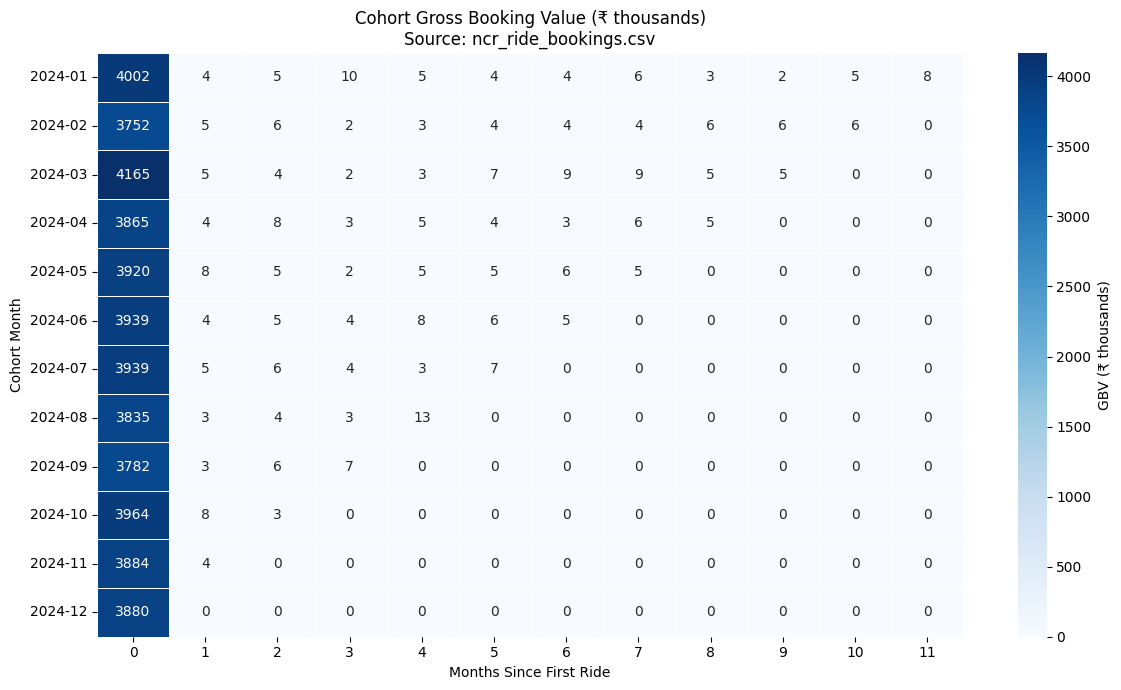

In [7]:
fig, ax = plt.subplots(figsize=(12, 7))
rev_cols = [c for c in sorted(rev_matrix.columns) if c <= 11]
rev_plot = rev_matrix[rev_cols].fillna(0)
sns.heatmap(rev_plot / 1000, annot=True, fmt='.0f', cmap='Blues',
            linewidths=0.4, ax=ax, cbar_kws={'label': 'GBV (₹ thousands)'})
ax.set_title('Cohort Gross Booking Value (₹ thousands)\nSource: ncr_ride_bookings.csv')
ax.set_xlabel('Months Since First Ride'); ax.set_ylabel('Cohort Month')
plt.tight_layout()
fig.savefig('outputs/plots/06_cohort_gbv_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

## 6.4 Key Cohort Findings

In [8]:
# Month-0 vs Month-1 drop (the critical churn point)
if 0 in rate_matrix.columns and 1 in rate_matrix.columns:
    m0_to_m1_drop = (rate_matrix[0] - rate_matrix[1].fillna(0)).mean()
    print(f'Average Month-0 → Month-1 retention drop: {m0_to_m1_drop:.1f} percentage points')

# Best-retention cohort
best_cohort = rate_matrix[1].fillna(0).idxmax() if 1 in rate_matrix.columns else 'N/A'
print(f'Cohort with best Month-1 retention: {best_cohort}')

# Trend: is retention improving for later cohorts?
if 1 in rate_matrix.columns:
    early = rate_matrix.iloc[:3][1].fillna(0).mean()
    late  = rate_matrix.iloc[-3:][1].fillna(0).mean()
    trend = 'improving' if late > early else 'declining'
    print(f'Month-1 retention trend (early vs late cohorts): {trend}  ({early:.1f}% → {late:.1f}%)')

Average Month-0 → Month-1 retention drop: 99.9 percentage points
Cohort with best Month-1 retention: 2024-01
Month-1 retention trend (early vs late cohorts): declining  (0.1% → 0.1%)


## Limitations
- True LTV cannot be calculated — no cost data (driver payout, commission, operating cost).
- All revenue figures are GBV only.
- With ~1 ride per customer on average, cohort retention is structurally low — this is treated as a genuine finding, not a data issue.

# Part 7: 07 Location Analysis

# Notebook 07 — Location Analysis

**Tier:** 1 / 2 — Descriptive & Diagnostic  
**Purpose:** Analyse ride volumes, performance, revenue, and directional flows by location and zone.  
**Input:** `outputs/feature_store.parquet`  
**Output:** Charts in `outputs/plots/07_*`, tables in `outputs/reports/`  

> Zone mapping is based on manual inspection of all 176 location names — methodology documented in
> `PROJECT_PLAN.md §2 Stage 2`. Unmapped locations are labelled 'Unknown'.

In [1]:
import os
os.chdir(r"D:\projects\Uber_Data_India_Analytics")
import sys, warnings, pathlib
sys.path.insert(0, '..')
warnings.filterwarnings('ignore')
pathlib.Path('outputs/plots').mkdir(parents=True, exist_ok=True)
pathlib.Path('outputs/reports').mkdir(parents=True, exist_ok=True)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

df = pd.read_parquet('outputs/feature_store.parquet')
completed = df[df['is_completed']].copy()
slot_order = ['Early Morning','Morning','Afternoon','Evening','Night','Late Night']
month_labels = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
print(f'Loaded feature store: {df.shape}  |  completed: {len(completed):,}')

Loaded feature store: (150000, 46)  |  completed: 93,000


## 7.1 Location Volume

In [2]:
top_pickup = df['Pickup Location'].value_counts().head(20)
top_drop   = df['Drop Location'].value_counts().head(20)
top_routes = df['route'].value_counts().head(20)

print('Top 10 Pickup Locations:'); print(top_pickup.head(10).to_string())
print(); print('Top 10 Drop Locations:');   print(top_drop.head(10).to_string())
print(); print('Top 10 Routes:');            print(top_routes.head(10).to_string())

Top 10 Pickup Locations:
Pickup Location
Khandsa             949
Barakhamba Road     946
Saket               931
Badarpur            921
Pragati Maidan      920
Madipur             919
AIIMS               918
Mehrauli            915
Dwarka Sector 21    914
Pataudi Chowk       907

Top 10 Drop Locations:
Drop Location
Ashram                936
Basai Dhankot         917
Lok Kalyan Marg       916
Narsinghpur           913
Cyber Hub             912
Kalkaji               912
Kashmere Gate ISBT    909
Udyog Vihar           906
Lajpat Nagar          904
Nehru Place           902

Top 10 Routes:
route
DLF City Court → Bhiwadi           17
Akshardham → RK Puram              16
Janakpuri → Faridabad Sector 15    16
Ghaziabad → Badshahpur             15
Rithala → Udyog Vihar Phase 4      15
Jor Bagh → Rohini East             15
Vatika Chowk → Rithala             15
Subhash Nagar → Basai Dhankot      14
Rohini West → Sohna Road           14
Chirag Delhi → Noida Film City     14


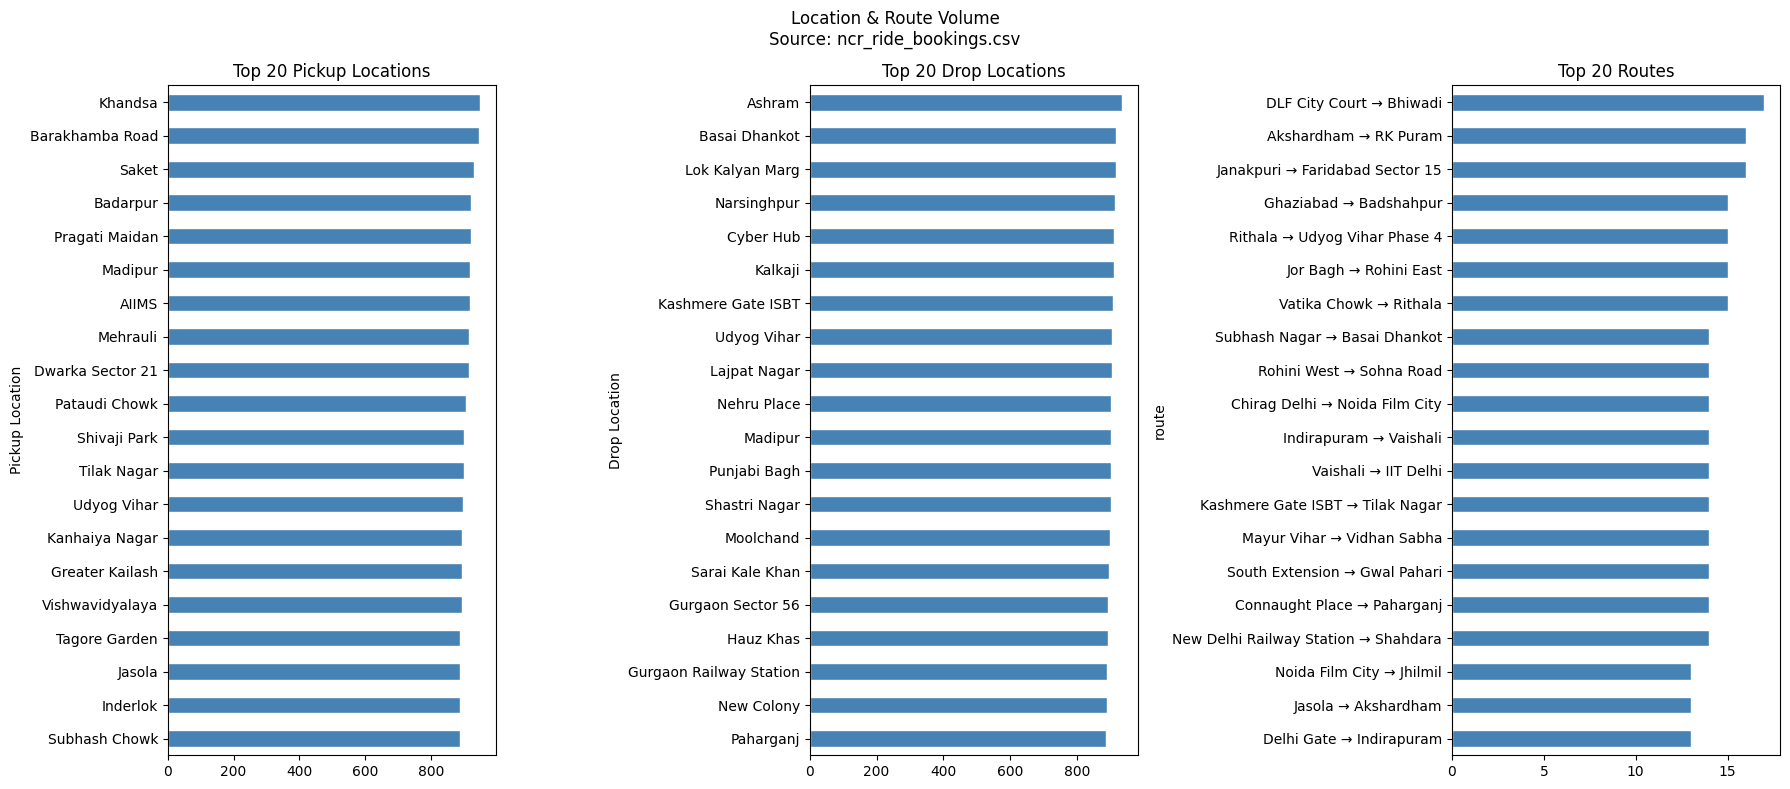

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(18, 8))
for ax, data, title in zip(axes,
        [top_pickup, top_drop, top_routes],
        ['Top 20 Pickup Locations', 'Top 20 Drop Locations', 'Top 20 Routes']):
    data.plot(kind='barh', ax=ax, color='steelblue', edgecolor='white')
    ax.set_title(title); ax.invert_yaxis()
fig.suptitle('Location & Route Volume\nSource: ncr_ride_bookings.csv')
plt.tight_layout()
fig.savefig('outputs/plots/07_top_locations.png', dpi=150, bbox_inches='tight')
plt.show()

In [4]:
zone_vol = df['pickup_zone'].value_counts()
print('Ride Volume by Pickup Zone:'); print(zone_vol.to_string())
unknown_pct = zone_vol.get('Unknown', 0) / len(df) * 100
print(f'  Unknown zone: {unknown_pct:.2f}% of rides')

Ride Volume by Pickup Zone:
pickup_zone
Delhi Core            32508
Delhi South           22140
Delhi North           19809
Gurgaon               16892
Delhi West            16347
Delhi East            15065
Gurgaon Peripheral    12878
Noida                  8495
Outer NCR              5035
Faridabad               831
  Unknown zone: 0.00% of rides


## 7.2 Location Performance

In [5]:
loc_perf = df.groupby('Pickup Location').agg(
    total_rides=('Booking ID', 'count'),
    completed=('is_completed', 'sum'),
    avg_booking_value=('Booking Value', 'mean'),
    avg_vtat=('Avg VTAT', 'mean'),
    ndf_count=('Booking Status', lambda s: (s == 'No Driver Found').sum()),
).round(2)
loc_perf['completion_rate_pct'] = (loc_perf['completed'] / loc_perf['total_rides'] * 100).round(1)
loc_perf['ndf_rate_pct'] = (loc_perf['ndf_count'] / loc_perf['total_rides'] * 100).round(1)
loc_perf = loc_perf.sort_values('total_rides', ascending=False)
loc_perf.to_csv('outputs/reports/location_performance.csv')
print('Top 15 Pickup Locations by Volume:')
print(loc_perf.head(15)[['total_rides','completion_rate_pct','avg_booking_value','avg_vtat','ndf_rate_pct']].to_string())
print('Saved: outputs/reports/location_performance.csv')

Top 15 Pickup Locations by Volume:
                  total_rides  completion_rate_pct  avg_booking_value  avg_vtat  ndf_rate_pct
Pickup Location                                                                              
Khandsa                   949                 63.2             511.33      8.38           6.4
Barakhamba Road           946                 62.8             518.47      8.45           6.1
Saket                     931                 59.8             474.02      8.60           7.0
Badarpur                  921                 61.6             521.01      8.74           6.7
Pragati Maidan            920                 58.5             503.84      8.36           7.6
Madipur                   919                 63.0             497.26      8.31           6.9
AIIMS                     918                 61.2             526.22      8.28           6.9
Mehrauli                  915                 62.7             484.95      8.24           7.8
Dwarka Sector 21         

In [6]:
# Worst supply locations: highest NDF rate (min 100 rides)
worst_supply = loc_perf[loc_perf['total_rides'] >= 100].nlargest(10, 'ndf_rate_pct')
print('Top 10 Pickup Locations by NDF Rate (min 100 bookings):')
print(worst_supply[['total_rides','ndf_rate_pct','avg_vtat']].to_string())

Top 10 Pickup Locations by NDF Rate (min 100 bookings):
                 total_rides  ndf_rate_pct  avg_vtat
Pickup Location                                     
Old Gurgaon              807          10.3      8.60
Paharganj                825           9.6      8.55
Vinobapuri               823           9.2      8.38
Rohini West              835           9.0      8.23
Greater Noida            866           8.9      8.44
Pataudi Chowk            907           8.8      8.50
Dwarka Mor               840           8.6      8.48
Arjangarh                810           8.6      8.56
Pitampura                851           8.5      8.39
Udyog Bhawan             838           8.5      8.49


## 7.3 Directional Flow (Zone-to-Zone)

In [7]:
zone_flow = df.groupby(['pickup_zone','drop_zone']).size().unstack(fill_value=0)
print('Zone-to-Zone Ride Volume:')
print(zone_flow.to_string())
zone_flow.to_csv('outputs/reports/zone_flow.csv')

# Intra vs inter zone
intra = sum(zone_flow.loc[z, z] for z in zone_flow.index if z in zone_flow.columns)
total_rides = len(df)
print(f'\nIntra-zone rides: {intra:,}  ({intra/total_rides*100:.1f}%)')
print(f'Inter-zone rides: {total_rides-intra:,}  ({(total_rides-intra)/total_rides*100:.1f}%)')

Zone-to-Zone Ride Volume:
drop_zone           Delhi Core  Delhi East  Delhi North  Delhi South  Delhi West  Faridabad  Gurgaon  Gurgaon Peripheral  Noida  Outer NCR
pickup_zone                                                                                                                               
Delhi Core                6842        3305         4270         4854        3492        182     3759                2859   1829       1116
Delhi East                3393        1429         1993         2177        1650         86     1722                1291    840        484
Delhi North               4249        2067         2485         2892        2186        106     2255                1695   1190        684
Delhi South               4922        2231         2949         3140        2371        137     2468                1862   1283        777
Delhi West                3691        1695         2111         2338        1720         99     1874                1369    912        538
F

## 7.4 Revenue by Location (GBV)

Top 15 Pickup Locations by GBV:
Pickup Location
Barakhamba Road     ₹309,713
Khandsa             ₹309,041
Pataudi Chowk       ₹306,774
Tughlakabad         ₹299,419
Subhash Chowk       ₹299,023
Badarpur            ₹298,309
Inderlok            ₹296,487
AIIMS               ₹296,028
ITO                 ₹292,168
Saidulajab          ₹291,251
Udyog Vihar         ₹291,078
Jama Masjid         ₹290,846
Botanical Garden    ₹290,768
IMT Manesar         ₹289,913
Greater Noida       ₹289,735


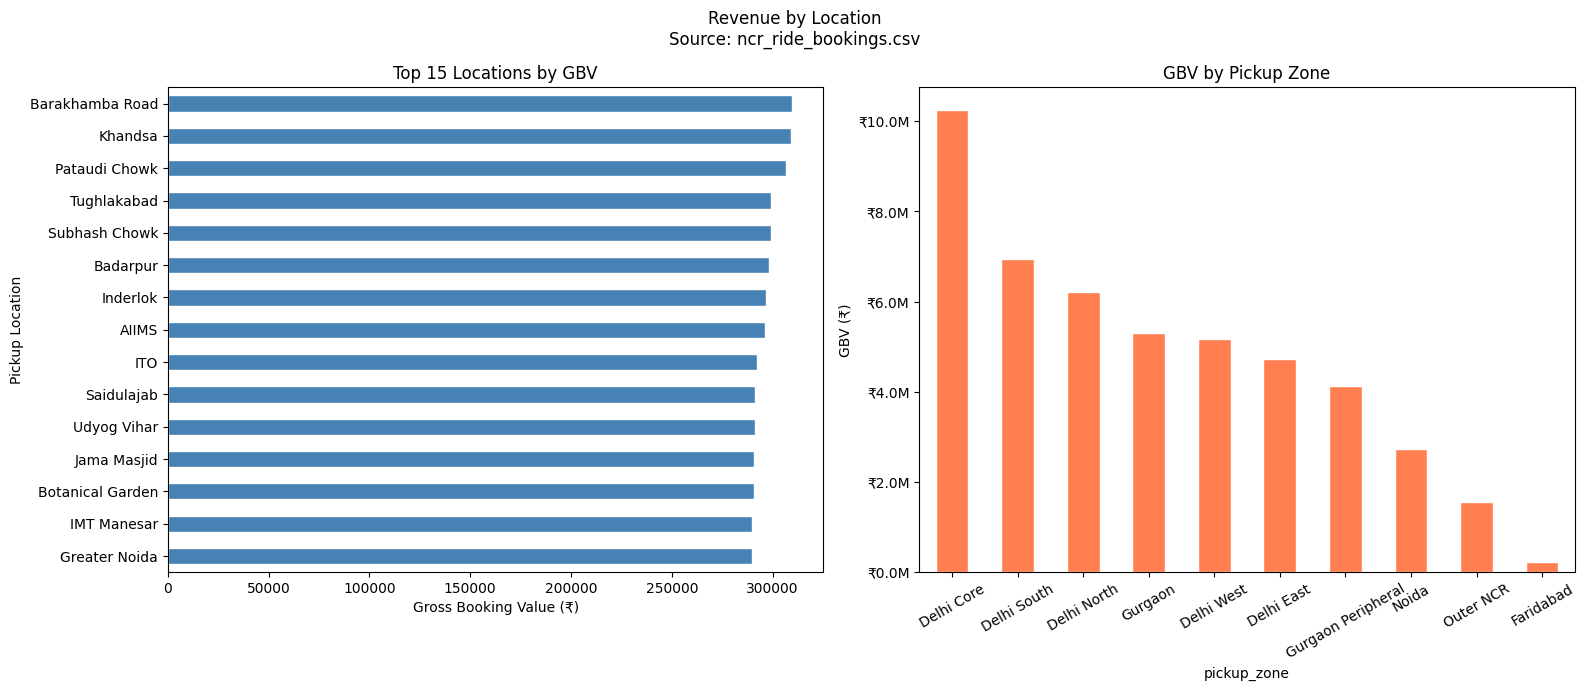

In [8]:
loc_gbv = completed.groupby('Pickup Location')['Booking Value'].sum().sort_values(ascending=False)
loc_fpk = completed.groupby('Pickup Location')['fare_per_km'].mean().sort_values(ascending=False)

print('Top 15 Pickup Locations by GBV:')
print(loc_gbv.head(15).apply(lambda x: f'₹{x:,.0f}').to_string())

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
loc_gbv.head(15).sort_values().plot(kind='barh', ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Top 15 Locations by GBV'); axes[0].set_xlabel('Gross Booking Value (₹)')
zone_gbv = completed.groupby('pickup_zone')['Booking Value'].sum().sort_values(ascending=False)
zone_gbv.plot(kind='bar', ax=axes[1], color='coral', edgecolor='white')
axes[1].set_title('GBV by Pickup Zone'); axes[1].set_ylabel('GBV (₹)')
axes[1].tick_params(axis='x', rotation=30)
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'₹{x/1e6:.1f}M'))
fig.suptitle('Revenue by Location\nSource: ncr_ride_bookings.csv')
plt.tight_layout()
fig.savefig('outputs/plots/07_location_revenue.png', dpi=150, bbox_inches='tight')
plt.show()

## Limitations
- Net revenue per location cannot be calculated (no cost data).
- Zone mapping covers all 176 locations — 'Unknown' entries are flagged but not force-assigned.

# Part 8: 08 Vehicle Fare Analysis

# Notebook 08 — Vehicle & Fare Analysis

**Tier:** 1 / 2 — Descriptive & Diagnostic  
**Purpose:** Compare vehicle types on supply, demand, fares, service quality, and GBV.  
**Input:** `outputs/feature_store.parquet`  
**Output:** Charts in `outputs/plots/08_*`, tables in `outputs/reports/`  

> ⚠️ Only **Gross Booking Value (GBV)** is reported. Driver payout, commission, net margin
> are **unavailable** — no cost fields exist in the dataset.

In [1]:
import os
os.chdir(r"D:\projects\Uber_Data_India_Analytics")
import sys, warnings, pathlib
sys.path.insert(0, '..')
warnings.filterwarnings('ignore')
pathlib.Path('outputs/plots').mkdir(parents=True, exist_ok=True)
pathlib.Path('outputs/reports').mkdir(parents=True, exist_ok=True)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

df = pd.read_parquet('outputs/feature_store.parquet')
completed = df[df['is_completed']].copy()
slot_order = ['Early Morning','Morning','Afternoon','Evening','Night','Late Night']
month_labels = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
print(f'Loaded feature store: {df.shape}  |  completed: {len(completed):,}')

Loaded feature store: (150000, 46)  |  completed: 93,000


## 8.1 Supply & Demand by Vehicle Type

In [2]:
veh = df.groupby('Vehicle Type', observed=True).agg(
    total_bookings=('Booking ID','count'),
    completed=('is_completed','sum'),
    ndf=('Booking Status', lambda s: (s=='No Driver Found').sum()),
    cancelled_driver=('Booking Status', lambda s: (s=='Cancelled by Driver').sum()),
    cancelled_cust=('Booking Status', lambda s: (s=='Cancelled by Customer').sum()),
    avg_vtat=('Avg VTAT','mean'),
    avg_ctat=('Avg CTAT','mean'),
).round(2)
veh['completion_rate_pct'] = (veh['completed']/veh['total_bookings']*100).round(1)
veh['ndf_rate_pct']        = (veh['ndf']/veh['total_bookings']*100).round(1)
veh['drv_canc_rate_pct']   = (veh['cancelled_driver']/veh['total_bookings']*100).round(1)
veh['cust_canc_rate_pct']  = (veh['cancelled_cust']/veh['total_bookings']*100).round(1)
veh = veh.sort_values('total_bookings', ascending=False)
print(veh[['total_bookings','completion_rate_pct','ndf_rate_pct',
           'drv_canc_rate_pct','cust_canc_rate_pct','avg_vtat']].to_string())

               total_bookings  completion_rate_pct  ndf_rate_pct  drv_canc_rate_pct  cust_canc_rate_pct  avg_vtat
Vehicle Type                                                                                                     
Auto                    37419                 61.9           7.2               17.8                 7.2      8.45
Go Mini                 29806                 62.2           6.8               17.9                 7.0      8.47
Go Sedan                27141                 61.4           7.2               18.5                 6.7      8.40
Bike                    22517                 62.3           6.7               18.1                 7.0      8.50
Premier Sedan           18111                 62.1           7.1               17.9                 7.0      8.44
eBike                   10557                 62.1           7.1               18.1                 6.8      8.48
Uber XL                  4449                 62.6           7.1               17.1     

## 8.2 Fare Analysis

In [3]:
fare_stats = completed.groupby('Vehicle Type', observed=True)['Booking Value'].describe(
    percentiles=[0.25,0.5,0.75]).round(0)
print('Fare distribution by Vehicle Type (₹):')
print(fare_stats.to_string())

fpk = completed.groupby('Vehicle Type', observed=True)['fare_per_km'].mean().sort_values(ascending=False)
print(); print('Avg Fare/km by Vehicle Type (₹/km):'); print(fpk.round(2).to_string())

Fare distribution by Vehicle Type (₹):
                 count   mean    std   min    25%    50%    75%     max
Vehicle Type                                                           
Auto           23155.0  506.0  391.0  50.0  233.0  413.0  688.0  4220.0
Bike           14034.0  509.0  401.0  50.0  234.0  415.0  689.0  4228.0
Go Mini        18549.0  507.0  395.0  50.0  233.0  412.0  689.0  4277.0
Go Sedan       16676.0  512.0  397.0  50.0  236.0  417.0  694.0  4088.0
Premier Sedan  11252.0  510.0  396.0  50.0  237.0  417.0  691.0  4008.0
Uber XL         2783.0  505.0  394.0  50.0  238.0  411.0  683.0  3703.0
eBike           6551.0  503.0  405.0  50.0  226.0  409.0  673.0  4093.0

Avg Fare/km by Vehicle Type (₹/km):
Vehicle Type
Go Sedan         34.66
Auto             34.00
Bike             33.89
Uber XL          33.85
Premier Sedan    33.73
Go Mini          33.49
eBike            32.47


TypeError: Axes.boxplot() got an unexpected keyword argument 'order'. Did you mean 'zorder'?

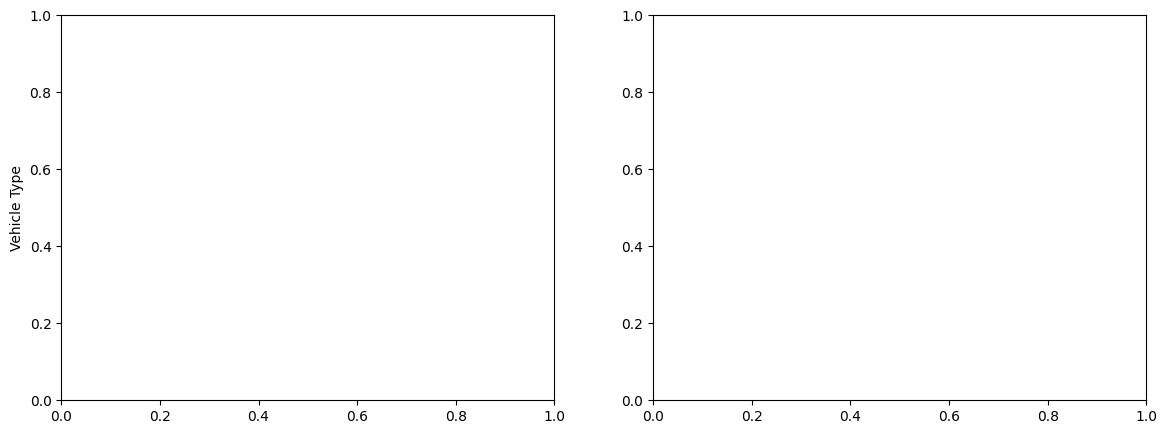

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
vehicle_order = veh.index.tolist()
completed.boxplot(column='Booking Value', by='Vehicle Type', ax=axes[0],
                  order=vehicle_order, vert=False)
axes[0].set_title('Fare Distribution by Vehicle Type (₹)')
axes[0].set_xlabel('Booking Value (₹)')
plt.sca(axes[0]); plt.title('Fare Distribution by Vehicle Type (₹)')

fpk_s = completed.groupby('time_slot', observed=True)['Booking Value'].mean().reindex(
    [s for s in slot_order if s in df['time_slot'].cat.categories])
fpk_s.plot(kind='bar', ax=axes[1], color='coral', edgecolor='white')
axes[1].set_title('Avg Fare by Time Slot (₹)'); axes[1].tick_params(axis='x', rotation=30)
fig.suptitle('Fare Analysis\nSource: ncr_ride_bookings.csv')
plt.tight_layout()
fig.savefig('outputs/plots/08_fare_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

## 8.3 Service Quality per Vehicle

In [ ]:
sq = completed.groupby('Vehicle Type', observed=True).agg(
    avg_driver_rating=('Driver Ratings','mean'),
    avg_customer_rating=('Customer Rating','mean'),
    avg_ride_distance=('Ride Distance','mean'),
    avg_booking_value=('Booking Value','mean'),
    gbv=('Booking Value','sum'),
).round(2)
sq['gbv_per_completed_ride'] = (sq['gbv'] / veh['completed']).round(0)
print('Service Quality by Vehicle Type:')
print(sq.to_string())
sq.to_csv('outputs/reports/vehicle_service_quality.csv')
print('\nSaved: outputs/reports/vehicle_service_quality.csv')

## 8.4 Revenue by Vehicle (GBV Only)

In [ ]:
gbv_veh = completed.groupby('Vehicle Type', observed=True)['Booking Value'].sum().sort_values(ascending=False)
print('Gross Booking Value by Vehicle Type:')
print(gbv_veh.apply(lambda x: f'₹{x:,.0f}').to_string())
print()
print('NOTE: Net revenue, driver payout, commission, and margin CANNOT be calculated')
print('      from this dataset — no cost fields are present.')

fig, ax = plt.subplots(figsize=(8, 5))
gbv_veh.plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')
ax.set_title('Gross Booking Value by Vehicle Type\nSource: ncr_ride_bookings.csv')
ax.set_ylabel('GBV (₹)'); ax.tick_params(axis='x', rotation=30)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'₹{x/1e6:.0f}M'))
plt.tight_layout()
fig.savefig('outputs/plots/08_gbv_by_vehicle.png', dpi=150, bbox_inches='tight')
plt.show()

## Limitations
- Net revenue, driver payout, commission, operating cost, and contribution margin are **unavailable**.
- Vehicle retirement recommendations require cost-side data not present in this dataset.

# Part 9: 09 Time Demand Analysis

# Notebook 09 — Time-Based Demand Analysis

**Tier:** 1 / 2 — Descriptive & Diagnostic  
**Purpose:** Understand hourly, daily, and monthly demand patterns.  
**Input:** `outputs/feature_store.parquet`  
**Output:** Charts in `outputs/plots/09_*`, tables in `outputs/reports/`

In [1]:
import os
os.chdir(r"D:\projects\Uber_Data_India_Analytics")
import sys, warnings, pathlib
sys.path.insert(0, '..')
warnings.filterwarnings('ignore')
pathlib.Path('outputs/plots').mkdir(parents=True, exist_ok=True)
pathlib.Path('outputs/reports').mkdir(parents=True, exist_ok=True)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

df = pd.read_parquet('outputs/feature_store.parquet')
completed = df[df['is_completed']].copy()
slot_order = ['Early Morning','Morning','Afternoon','Evening','Night','Late Night']
month_labels = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
print(f'Loaded feature store: {df.shape}  |  completed: {len(completed):,}')

Loaded feature store: (150000, 46)  |  completed: 93,000


## 9.1 Hourly Demand

In [2]:
hourly = df.groupby('hour').agg(
    bookings=('Booking ID','count'),
    completed=('is_completed','sum'),
    cancelled=('is_cancelled','sum'),
    avg_vtat=('Avg VTAT','mean'),
    avg_fare=('Booking Value','mean'),
).round(2)
hourly['completion_rate_pct'] = (hourly['completed']/hourly['bookings']*100).round(1)
hourly['cancellation_rate_pct'] = (hourly['cancelled']/hourly['bookings']*100).round(1)
print('Hourly stats (first 12 hours):')
print(hourly.head(12).to_string())

Hourly stats (first 12 hours):
      bookings  completed  cancelled  avg_vtat  avg_fare  completion_rate_pct  cancellation_rate_pct
hour                                                                                                
0         1373        858        340      8.41    507.77                 62.5                   24.8
1         1360        828        344      8.39    515.64                 60.9                   25.3
2         1339        853        297      8.55    508.92                 63.7                   22.2
3         1383        860        355      8.36    505.72                 62.2                   25.7
4         1321        830        338      8.54    508.94                 62.8                   25.6
5         2786       1715        736      8.45    499.58                 61.6                   26.4
6         4160       2609       1005      8.47    516.70                 62.7                   24.2
7         5450       3346       1382      8.45    503.10    

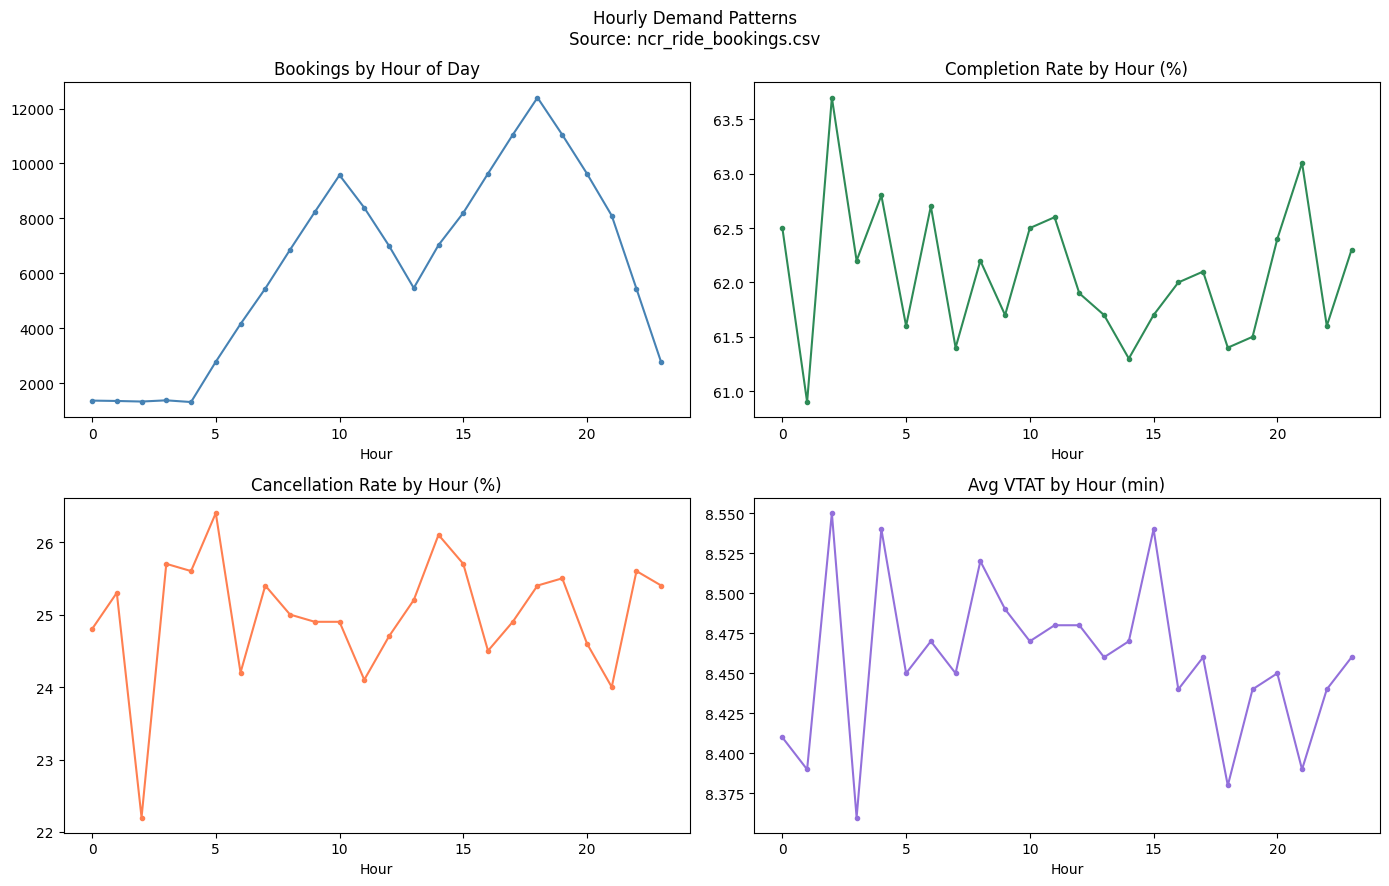

In [3]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
hourly['bookings'].plot(ax=axes[0,0], color='steelblue', marker='.')
axes[0,0].set_title('Bookings by Hour of Day'); axes[0,0].set_xlabel('Hour')

hourly['completion_rate_pct'].plot(ax=axes[0,1], color='seagreen', marker='.')
axes[0,1].set_title('Completion Rate by Hour (%)'); axes[0,1].set_xlabel('Hour')

hourly['cancellation_rate_pct'].plot(ax=axes[1,0], color='coral', marker='.')
axes[1,0].set_title('Cancellation Rate by Hour (%)'); axes[1,0].set_xlabel('Hour')

hourly['avg_vtat'].plot(ax=axes[1,1], color='mediumpurple', marker='.')
axes[1,1].set_title('Avg VTAT by Hour (min)'); axes[1,1].set_xlabel('Hour')

fig.suptitle('Hourly Demand Patterns\nSource: ncr_ride_bookings.csv')
plt.tight_layout()
fig.savefig('outputs/plots/09_hourly_patterns.png', dpi=150, bbox_inches='tight')
plt.show()

## 9.2 Day-of-Week Demand

Day-of-Week stats:
           bookings  completed        gbv  completion_rate_pct  avg_fare
day_name                                                                
Monday        21644      13318  6414387.0                 61.5     482.0
Tuesday       21391      13171  6416890.0                 61.6     487.0
Wednesday     21413      13296  6578787.0                 62.1     495.0
Thursday      21215      13206  6557680.0                 62.2     497.0
Friday        21397      13253  6674597.0                 61.9     504.0
Saturday      21542      13442  9571155.0                 62.4     712.0
Sunday        21398      13314  9632687.0                 62.2     724.0


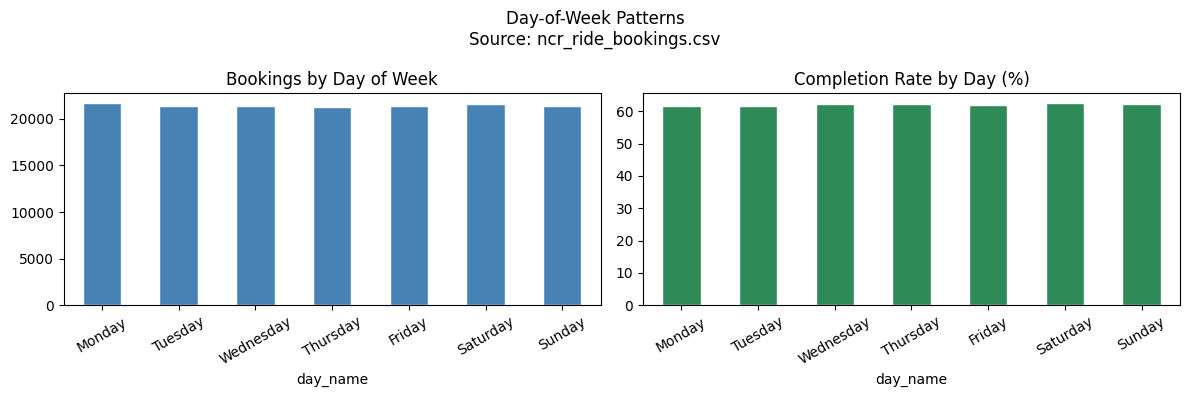

In [4]:
dow_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
dow = df.groupby('day_name').agg(
    bookings=('Booking ID','count'),
    completed=('is_completed','sum'),
    gbv=('Booking Value','sum'),
).reindex(dow_order).round(2)
dow['completion_rate_pct'] = (dow['completed']/dow['bookings']*100).round(1)
dow['avg_fare'] = (dow['gbv'] / dow['completed']).round(0)
print('Day-of-Week stats:'); print(dow.to_string())

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
dow['bookings'].plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Bookings by Day of Week'); axes[0].tick_params(axis='x', rotation=30)
dow['completion_rate_pct'].plot(kind='bar', ax=axes[1], color='seagreen', edgecolor='white')
axes[1].set_title('Completion Rate by Day (%)'); axes[1].tick_params(axis='x', rotation=30)
fig.suptitle('Day-of-Week Patterns\nSource: ncr_ride_bookings.csv')
plt.tight_layout()
fig.savefig('outputs/plots/09_dow_patterns.png', dpi=150, bbox_inches='tight')
plt.show()

## 9.3 Monthly Seasonality

Monthly stats:
     bookings  completed        gbv  avg_fare  completion_rate_pct
Jan     12861       7951  4411069.0    503.60                 61.8
Feb     11927       7368  4085790.0    507.61                 61.8
Mar     12719       7954  4568188.0    526.23                 62.5
Apr     12199       7632  4253789.0    509.01                 62.6
May     12778       7905  4320679.0    498.18                 61.9
Jun     12440       7757  4325660.0    509.20                 62.4
Jul     12897       7926  4365923.0    500.16                 61.5
Aug     12636       7780  4243509.0    498.36                 61.6
Sep     12248       7542  4191393.0    505.90                 61.6
Oct     12651       7905  4417170.0    509.71                 62.5
Nov     12394       7659  4343395.0    514.07                 61.8
Dec     12250       7621  4319618.0    517.82                 62.2


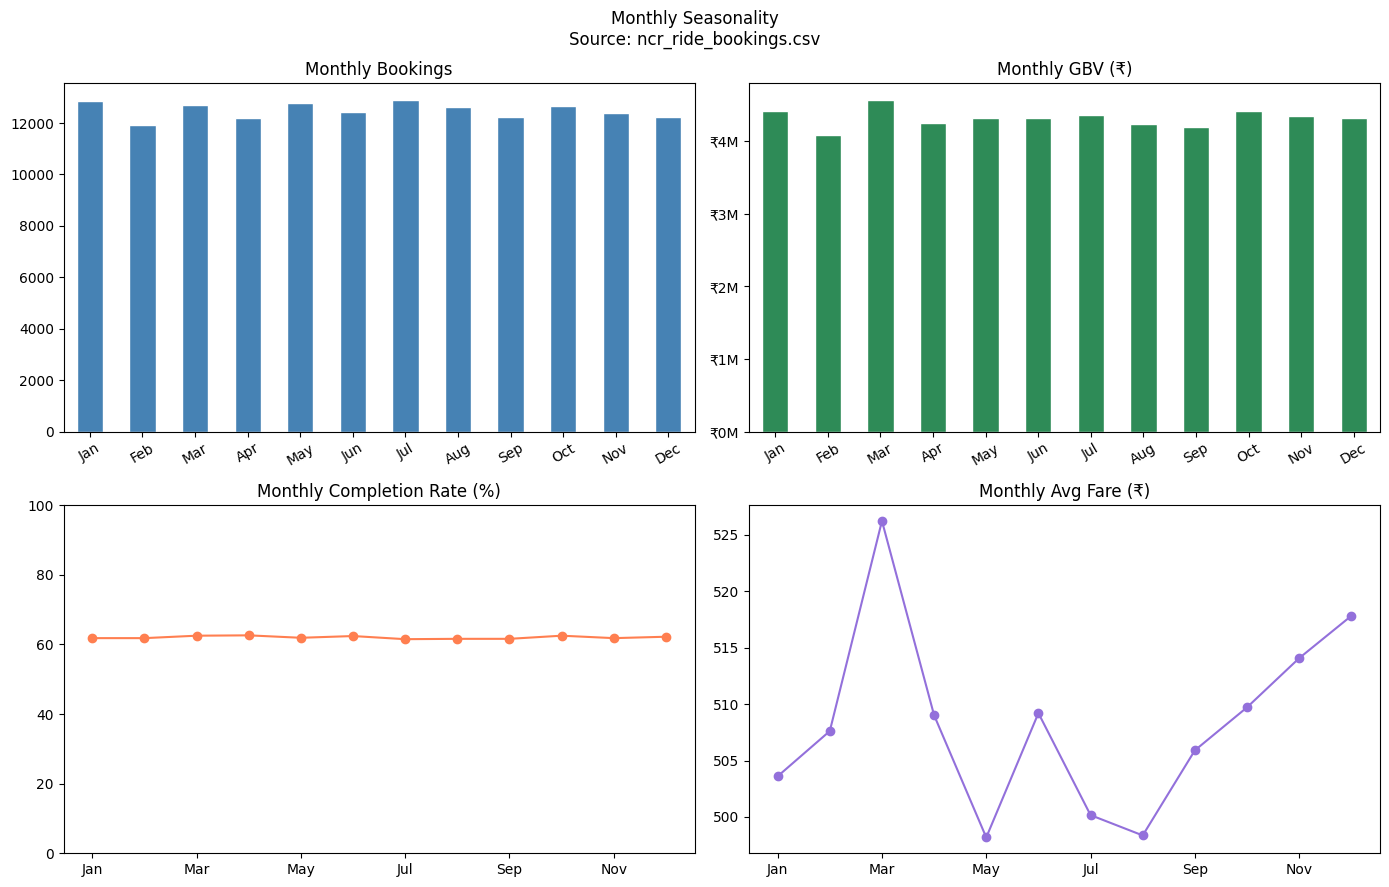

In [5]:
monthly = df.groupby('month').agg(
    bookings=('Booking ID','count'),
    completed=('is_completed','sum'),
    gbv=('Booking Value','sum'),
    avg_fare=('Booking Value','mean'),
).round(2)
monthly['completion_rate_pct'] = (monthly['completed']/monthly['bookings']*100).round(1)
monthly.index = month_labels
print('Monthly stats:'); print(monthly.to_string())
monthly.to_csv('outputs/reports/monthly_stats.csv')

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
monthly['bookings'].plot(kind='bar', ax=axes[0,0], color='steelblue', edgecolor='white')
axes[0,0].set_title('Monthly Bookings'); axes[0,0].tick_params(axis='x', rotation=30)
monthly['gbv'].plot(kind='bar', ax=axes[0,1], color='seagreen', edgecolor='white')
axes[0,1].set_title('Monthly GBV (₹)'); axes[0,1].tick_params(axis='x', rotation=30)
axes[0,1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'₹{x/1e6:.0f}M'))
monthly['completion_rate_pct'].plot(ax=axes[1,0], marker='o', color='coral')
axes[1,0].set_title('Monthly Completion Rate (%)'); axes[1,0].set_ylim(0,100)
monthly['avg_fare'].plot(ax=axes[1,1], marker='o', color='mediumpurple')
axes[1,1].set_title('Monthly Avg Fare (₹)')
fig.suptitle('Monthly Seasonality\nSource: ncr_ride_bookings.csv')
plt.tight_layout()
fig.savefig('outputs/plots/09_monthly_seasonality.png', dpi=150, bbox_inches='tight')
plt.show()

## 9.4 Time-Slot Analysis

Time Slot stats:
               bookings  completed  avg_vtat  avg_fare  avg_driver_rating  completion_rate_pct
time_slot                                                                                     
Early Morning      9562       5944      8.45    506.55               4.23                 62.2
Morning           34282      21289      8.48    512.12               4.23                 62.1
Afternoon         27897      17278      8.47    505.08               4.23                 61.9
Evening           52323      32302      8.45    506.68               4.23                 61.7
Night             23174      14465      8.43    509.72               4.24                 62.4
Late Night         2762       1722      8.46    517.68               4.22                 62.3


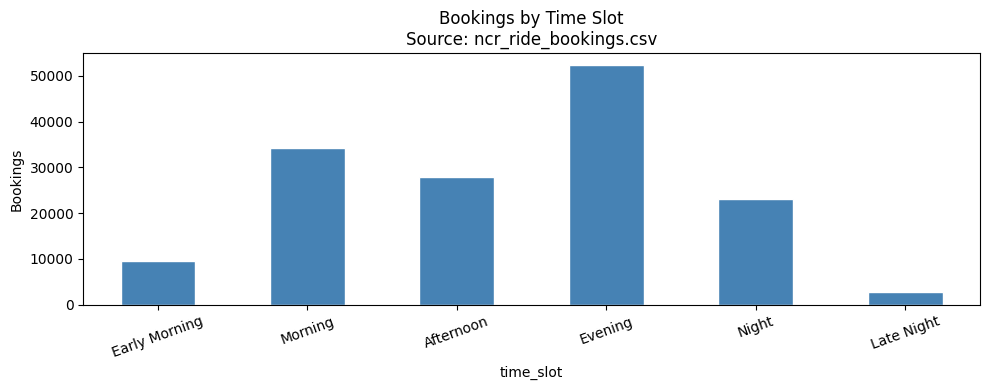

In [6]:
slot_stats = df.groupby('time_slot', observed=True).agg(
    bookings=('Booking ID','count'),
    completed=('is_completed','sum'),
    avg_vtat=('Avg VTAT','mean'),
    avg_fare=('Booking Value','mean'),
    avg_driver_rating=('Driver Ratings','mean'),
).reindex([s for s in slot_order if s in df['time_slot'].cat.categories]).round(2)
slot_stats['completion_rate_pct'] = (slot_stats['completed']/slot_stats['bookings']*100).round(1)
print('Time Slot stats:'); print(slot_stats.to_string())

fig, ax = plt.subplots(figsize=(10, 4))
slot_stats['bookings'].plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')
ax.set_title('Bookings by Time Slot\nSource: ncr_ride_bookings.csv')
ax.set_ylabel('Bookings'); ax.tick_params(axis='x', rotation=20)
plt.tight_layout()
fig.savefig('outputs/plots/09_slot_bookings.png', dpi=150, bbox_inches='tight')
plt.show()

## 9.5 Weekend vs Weekday

In [7]:
we = df.groupby('is_weekend').agg(
    bookings=('Booking ID','count'),
    completed=('is_completed','sum'),
    gbv=('Booking Value','sum'),
    avg_fare=('Booking Value','mean'),
).round(2)
we.index = ['Weekday','Weekend']
we['completion_rate_pct'] = (we['completed']/we['bookings']*100).round(1)
print('Weekend vs Weekday:'); print(we.to_string())

Weekend vs Weekday:
         bookings  completed         gbv  avg_fare  completion_rate_pct
Weekday    107060      66244  32642341.0    448.99                 61.9
Weekend     42940      26756  19203842.0    655.47                 62.3


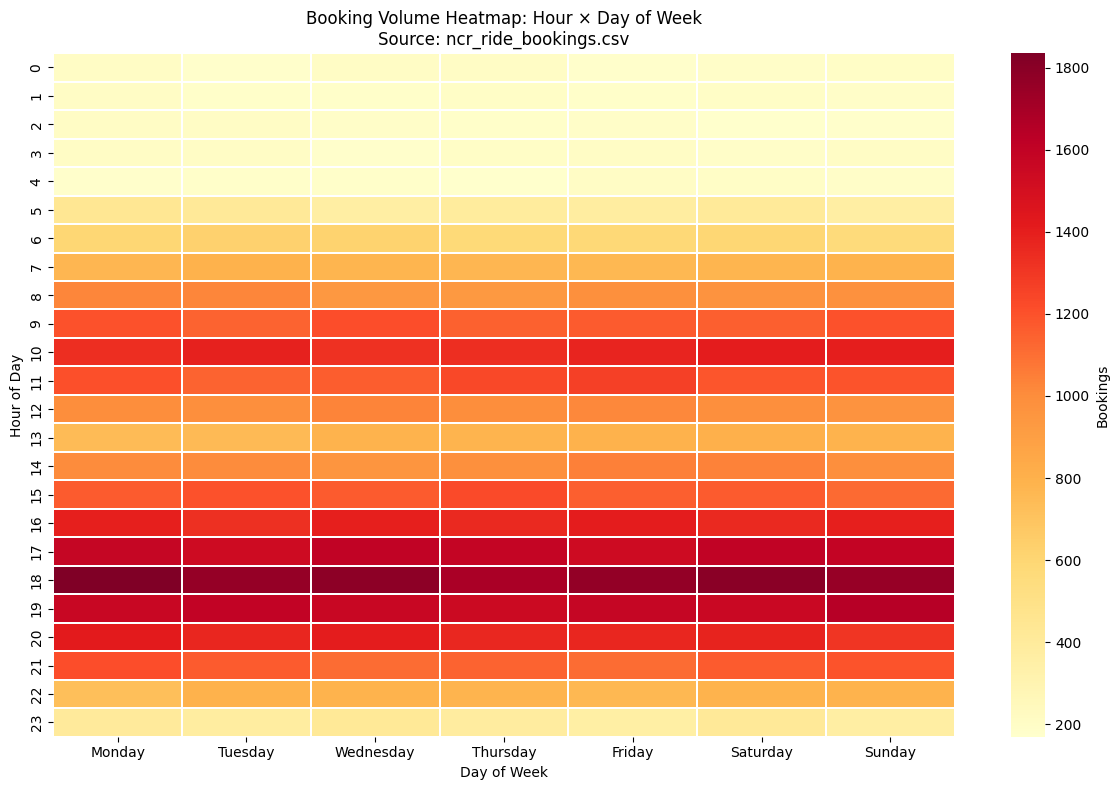

In [8]:
# Demand heatmap: hour x day_of_week
heat = df.pivot_table(index='hour', columns='day_name', values='Booking ID',
                      aggfunc='count', fill_value=0)[dow_order]
fig, ax = plt.subplots(figsize=(12, 8))
sns.heatmap(heat, cmap='YlOrRd', ax=ax, linewidths=0.3,
            cbar_kws={'label': 'Bookings'})
ax.set_title('Booking Volume Heatmap: Hour × Day of Week\nSource: ncr_ride_bookings.csv')
ax.set_xlabel('Day of Week'); ax.set_ylabel('Hour of Day')
plt.tight_layout()
fig.savefig('outputs/plots/09_heatmap_hour_dow.png', dpi=150, bbox_inches='tight')
plt.show()

## Limitations
- No external event or weather data to explain specific demand spikes.

# Part 10: 10 Cancellation Analysis

# Notebook 10 — Cancellation Analysis

**Tier:** 1 / 2 — Descriptive & Diagnostic  
**Purpose:** In-depth analysis of all cancellation types, reasons, trends and estimated impact.  
**Input:** `outputs/feature_store.parquet`  
**Output:** Charts in `outputs/plots/10_*`, tables in `outputs/reports/`

In [1]:
import os
os.chdir(r"D:\projects\Uber_Data_India_Analytics")
import sys, warnings, pathlib
sys.path.insert(0, '..')
warnings.filterwarnings('ignore')
pathlib.Path('outputs/plots').mkdir(parents=True, exist_ok=True)
pathlib.Path('outputs/reports').mkdir(parents=True, exist_ok=True)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

df = pd.read_parquet('outputs/feature_store.parquet')
completed = df[df['is_completed']].copy()
slot_order = ['Early Morning','Morning','Afternoon','Evening','Night','Late Night']
month_labels = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
print(f'Loaded feature store: {df.shape}  |  completed: {len(completed):,}')

Loaded feature store: (150000, 46)  |  completed: 93,000


## 10.1 Overall Cancellation Landscape

In [2]:
n_total = len(df)
n_canc_c  = (df['Booking Status'] == 'Cancelled by Customer').sum()
n_canc_d  = (df['Booking Status'] == 'Cancelled by Driver').sum()
n_ndf     = (df['Booking Status'] == 'No Driver Found').sum()
n_incomplete = (df['Booking Status'] == 'Incomplete').sum()
n_failed  = n_canc_c + n_canc_d + n_ndf + n_incomplete

print(f'Total bookings              : {n_total:,}')
print(f'Overall failure rate        : {n_failed/n_total*100:.1f}%')
print(f'  Cancelled by Customer     : {n_canc_c:,}  ({n_canc_c/n_total*100:.1f}%)')
print(f'  Cancelled by Driver       : {n_canc_d:,}  ({n_canc_d/n_total*100:.1f}%)')
print(f'  No Driver Found           : {n_ndf:,}  ({n_ndf/n_total*100:.1f}%)')
print(f'  Incomplete                : {n_incomplete:,}  ({n_incomplete/n_total*100:.1f}%)')

Total bookings              : 150,000
Overall failure rate        : 38.0%
  Cancelled by Customer     : 10,500  (7.0%)
  Cancelled by Driver       : 27,000  (18.0%)
  No Driver Found           : 10,500  (7.0%)
  Incomplete                : 9,000  (6.0%)


## 10.2 Customer Cancellations

In [3]:
cust_canc = df[df['Booking Status'] == 'Cancelled by Customer'].copy()
print('Customer cancellation reasons:')
print(cust_canc['Reason for cancelling by Customer'].value_counts().to_string())
print()
print('Customer cancellation by Vehicle Type:')
print(cust_canc.groupby('Vehicle Type', observed=True).size().sort_values(ascending=False).to_string())

Customer cancellation reasons:
Reason for cancelling by Customer
Wrong Address                                   2362
Change of plans                                 2353
Driver is not moving towards pickup location    2335
Driver asked to cancel                          2295
AC is not working                               1155

Customer cancellation by Vehicle Type:
Vehicle Type
Auto             2680
Go Mini          2097
Go Sedan         1832
Bike             1575
Premier Sedan    1266
eBike             723
Uber XL           327


In [4]:
# VTAT at time of customer cancellation (is high VTAT driving cancellations?)
cc_vtat = cust_canc['Avg VTAT'].dropna()
all_vtat = df[df['Avg VTAT'].notna()]['Avg VTAT']
print(f'Avg VTAT for customer-cancelled rides : {cc_vtat.mean():.2f} min')
print(f'Avg VTAT for all dispatched rides     : {all_vtat.mean():.2f} min')
print(f'Difference                            : {cc_vtat.mean() - all_vtat.mean():+.2f} min')

Avg VTAT for customer-cancelled rides : 12.51 min
Avg VTAT for all dispatched rides     : 8.46 min
Difference                            : +4.06 min


Monthly customer cancellation rate (%):
month
1     6.9
2     7.0
3     7.1
4     6.4
5     7.2
6     7.1
7     7.2
8     6.6
9     7.3
10    7.1
11    7.0
12    7.1


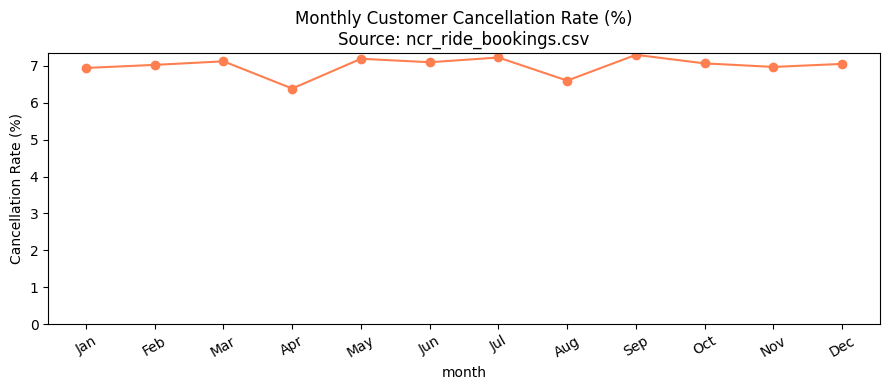

In [5]:
# Monthly customer cancellation rate trend
monthly_cc = df.groupby('month').apply(
    lambda g: (g['Booking Status'] == 'Cancelled by Customer').sum() / len(g) * 100
).rename('cust_canc_pct')
print('Monthly customer cancellation rate (%):')
print(monthly_cc.round(1).to_string())

fig, ax = plt.subplots(figsize=(9, 4))
monthly_cc.plot(marker='o', ax=ax, color='coral')
ax.set_title('Monthly Customer Cancellation Rate (%)\nSource: ncr_ride_bookings.csv')
ax.set_xticks(range(1,13)); ax.set_xticklabels(month_labels, rotation=30)
ax.set_ylabel('Cancellation Rate (%)'); ax.set_ylim(0, None)
plt.tight_layout()
fig.savefig('outputs/plots/10_monthly_cust_canc.png', dpi=150, bbox_inches='tight')
plt.show()

## 10.3 Driver Cancellations

In [6]:
drv_canc = df[df['Booking Status'] == 'Cancelled by Driver'].copy()
print('Driver cancellation reasons:')
print(drv_canc['Driver Cancellation Reason'].value_counts().to_string())
print()
print('Driver cancellation by Vehicle Type:')
print(drv_canc.groupby('Vehicle Type', observed=True).size().sort_values(ascending=False).to_string())
print()
drv_slot = (drv_canc.groupby('time_slot', observed=True).size()
            .reindex([s for s in slot_order if s in df['time_slot'].cat.categories]))
print('Driver cancellation by Time Slot:')
print(drv_slot.to_string())

Driver cancellation reasons:
Driver Cancellation Reason
Customer related issue                 6837
The customer was coughing/sick         6751
Personal & Car related issues          6726
More than permitted people in there    6686

Driver cancellation by Vehicle Type:
Vehicle Type
Auto             6643
Go Mini          5330
Go Sedan         5031
Bike             4077
Premier Sedan    3250
eBike            1907
Uber XL           762

Driver cancellation by Time Slot:
time_slot
Early Morning    1755
Morning          6133
Afternoon        5027
Evening          9458
Night            4141
Late Night        486


## 10.4 Cancellation Revenue Impact Estimate

In [7]:
median_fare = completed['Booking Value'].median()
avg_fare    = completed['Booking Value'].mean()

# Upper-bound scenario: ALL cancelled rides would have completed at average fare
scenario_upper = (n_canc_c + n_canc_d) * avg_fare

print(f'Avg fare (completed rides)   : ₹{avg_fare:,.0f}')
print(f'Median fare (completed rides): ₹{median_fare:,.0f}')
print()
print(f'Total cancelled bookings (Customer + Driver): {n_canc_c + n_canc_d:,}')
print()
print(f'Revenue impact SCENARIO (if all cancelled → completed at avg fare):')
print(f'  ₹{scenario_upper:,.0f}')
print()
print('⚠ WARNING: This is a hypothetical upper-bound SCENARIO ESTIMATE only.')
print('   It assumes every cancelled ride would have completed at average fare,')
print('   which is not guaranteed. Actual recoverable revenue would be lower.')
print('   Net revenue cannot be estimated — no cost data available.')

Avg fare (completed rides)   : ₹508
Median fare (completed rides): ₹414

Total cancelled bookings (Customer + Driver): 37,500

Revenue impact SCENARIO (if all cancelled → completed at avg fare):
  ₹19,056,683

⚠ WARNING: This is a hypothetical upper-bound SCENARIO ESTIMATE only.
   It assumes every cancelled ride would have completed at average fare,
   which is not guaranteed. Actual recoverable revenue would be lower.
   Net revenue cannot be estimated — no cost data available.


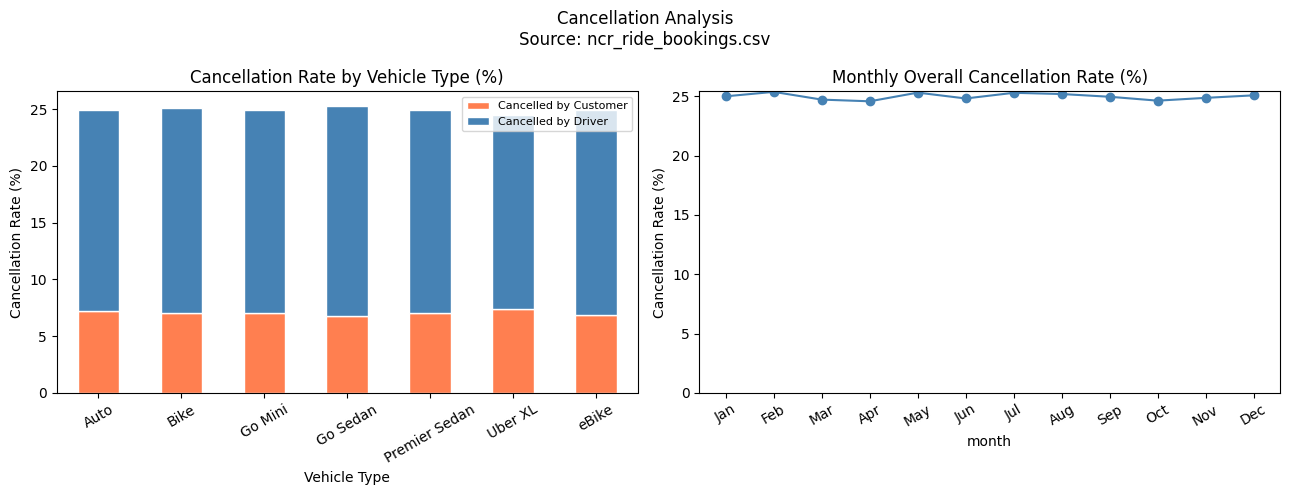

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Cancellation rate by vehicle type (stacked by party)
vc = df.groupby('Vehicle Type', observed=True).agg(
    canc_cust=('Booking Status', lambda s: (s=='Cancelled by Customer').sum()),
    canc_drv=('Booking Status', lambda s: (s=='Cancelled by Driver').sum()),
    total=('Booking ID','count')
)
vc[['canc_cust','canc_drv']].div(vc['total'], axis=0).mul(100).plot(
    kind='bar', stacked=True, ax=axes[0], color=['coral','steelblue'], edgecolor='white')
axes[0].set_title('Cancellation Rate by Vehicle Type (%)')
axes[0].set_ylabel('Cancellation Rate (%)'); axes[0].tick_params(axis='x', rotation=30)
axes[0].legend(['Cancelled by Customer','Cancelled by Driver'], fontsize=8)

# Monthly overall cancellation rate
monthly_all_canc = df.groupby('month').apply(
    lambda g: g['is_cancelled'].sum() / len(g) * 100).rename('canc_pct')
monthly_all_canc.plot(marker='o', ax=axes[1], color='steelblue')
axes[1].set_title('Monthly Overall Cancellation Rate (%)')
axes[1].set_xticks(range(1,13)); axes[1].set_xticklabels(month_labels, rotation=30)
axes[1].set_ylabel('Cancellation Rate (%)'); axes[1].set_ylim(0, None)

fig.suptitle('Cancellation Analysis\nSource: ncr_ride_bookings.csv')
plt.tight_layout()
fig.savefig('outputs/plots/10_cancellation_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

## Limitations
- No driver ID — cannot attribute driver cancellations to specific repeat offenders.
- Revenue impact estimate is a hypothetical upper-bound scenario, not a forecast.
- No cost data → cannot estimate net margin impact of cancellations.

# Part 11: 11 Predictive Ml

# Notebook 11 — Predictive Analytics / Machine Learning

**Tier:** 3 — Predictive  
**Purpose:**  
  - **Task A:** Predict whether a booking will be Completed (binary classification).  
  - **Task B:** Estimate fare for a completed ride (regression).  
**Input:** `outputs/feature_store.parquet`  
**Output:** `outputs/models/`, `outputs/reports/ml_results.csv`, charts  

**Leakage prevention:** All post-outcome columns are strictly excluded.  
Customer history features use time-sorted rolling (only prior bookings).  
Train/test split is time-based only (train ≤ Sep 2024, test ≥ Oct 2024).  
No hardcoded ROC-AUC threshold — performance is reported and interpreted in business context.  

**Model stages:**  
Stage 1 (mandatory): Logistic Regression → Random Forest  
Stage 2 (conditional): Gradient boosting only if Stage 1 is insufficient and complexity is justified.

In [1]:
import os
os.chdir(r"D:\projects\Uber_Data_India_Analytics")
import sys, warnings, pathlib
sys.path.insert(0, '..')
warnings.filterwarnings('ignore')
pathlib.Path('outputs/plots').mkdir(parents=True, exist_ok=True)
pathlib.Path('outputs/reports').mkdir(parents=True, exist_ok=True)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

df = pd.read_parquet('outputs/feature_store.parquet')
completed = df[df['is_completed']].copy()
slot_order = ['Early Morning','Morning','Afternoon','Evening','Night','Late Night']
month_labels = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
print(f'Loaded feature store: {df.shape}  |  completed: {len(completed):,}')

Loaded feature store: (150000, 46)  |  completed: 93,000


## 11.1 Load Data & Add Rolling Customer Features

In [2]:
from src.ml_pipeline import (
    add_rolling_customer_features, fit_target_encoding, apply_target_encoding,
    build_feature_matrix_classification, time_split, train_classify,
    evaluate_classifier, build_fare_features, train_fare_model, evaluate_regressor,
    EXCLUDED_COLUMNS
)

# Add time-safe rolling customer history features
df_ml = add_rolling_customer_features(df.copy())
print(f'Added rolling features. Shape: {df_ml.shape}')
print(df_ml[['Customer ID','datetime','customer_prior_rides',
             'customer_prior_completion_rate']].head(8).to_string())

Added rolling features. Shape: (150000, 49)
  Customer ID            datetime  customer_prior_rides  customer_prior_completion_rate
0  CID8362794 2024-01-01 00:19:34                     0                             NaN
1  CID8300238 2024-01-01 01:35:18                     0                             NaN
2  CID2030746 2024-01-01 01:37:50                     0                             NaN
3  CID3231181 2024-01-01 01:48:03                     0                             NaN
4  CID3381661 2024-01-01 01:49:56                     0                             NaN
5  CID9268400 2024-01-01 01:53:01                     0                             NaN
6  CID6577042 2024-01-01 02:14:50                     0                             NaN
7  CID3289424 2024-01-01 02:43:46                     0                             NaN


## 11.2 Time-Based Train / Test Split

In [3]:
train_df, test_df = time_split(df_ml)
print(f'Train date range: {train_df["datetime"].min().date()} → {train_df["datetime"].max().date()}')
print(f'Test  date range: {test_df["datetime"].min().date()} → {test_df["datetime"].max().date()}')
print(f'Train target balance: {train_df["is_completed"].mean()*100:.1f}% completed')
print(f'Test  target balance: {test_df["is_completed"].mean()*100:.1f}% completed')

[SPLIT] Train: 112,705 rows  |  Test: 37,295 rows
Train date range: 2024-01-01 → 2024-09-30
Test  date range: 2024-10-01 → 2024-12-30
Train target balance: 61.9% completed
Test  target balance: 62.2% completed


## 11.3 Target Encoding (fitted on train only)

In [4]:
loc_cols = ['Pickup Location', 'Drop Location']
target_col = 'is_completed'
encodings = fit_target_encoding(train_df, target_col, loc_cols, smoothing=10.0)
global_fallback = train_df[target_col].mean()
print(f'Global completion rate (train): {global_fallback:.4f}')
print(f'Sample Pickup Location encodings (first 5):')
for k, v in list(encodings['Pickup Location'].items())[:5]:
    print(f'  {k}: {v:.4f}')

Global completion rate (train): 0.6194
Sample Pickup Location encodings (first 5):
  AIIMS: 0.6168
  Adarsh Nagar: 0.6091
  Akshardham: 0.5439
  Ambience Mall: 0.6350
  Anand Vihar: 0.6505


## 11.4 Build Feature Matrices

In [5]:
X_train, y_train = build_feature_matrix_classification(train_df, encodings, global_fallback, is_train=True)
X_test,  y_test  = build_feature_matrix_classification(test_df,  encodings, global_fallback, is_train=False)

print(f'X_train shape: {X_train.shape}  |  y_train balance: {y_train.mean()*100:.1f}%')
print(f'X_test  shape: {X_test.shape}   |  y_test  balance: {y_test.mean()*100:.1f}%')
print(f'\nFeatures used ({len(X_train.columns)}):')
print(list(X_train.columns))

# Verify no excluded columns leaked into feature matrix
from src.ml_pipeline import EXCLUDED_COLUMNS
leaked = set(X_train.columns) & EXCLUDED_COLUMNS
assert len(leaked) == 0, f'Leakage detected: {leaked}'
print('\n✓ No post-outcome columns in feature matrix.')

X_train shape: (112705, 20)  |  y_train balance: 61.9%
X_test  shape: (37295, 20)   |  y_test  balance: 62.2%

Features used (20):
['hour', 'day_of_week', 'month', 'is_weekend', 'Avg VTAT', 'Avg CTAT', 'customer_prior_rides', 'customer_prior_completion_rate', 'customer_prior_cancellation_rate', 'pickup_location_enc', 'drop_location_enc', 'time_slot_enc', 'months_since_first', 'vehicle_Auto', 'vehicle_Bike', 'vehicle_Go Mini', 'vehicle_Go Sedan', 'vehicle_Premier Sedan', 'vehicle_Uber XL', 'vehicle_eBike']

✓ No post-outcome columns in feature matrix.


## 11.5 Stage 1 — Logistic Regression (Baseline)

In [6]:
pipe_lr = train_classify(X_train, y_train, model_name='logistic')
metrics_lr = evaluate_classifier(pipe_lr, X_test, y_test, 'Logistic Regression')

[OK] Trained logistic classifier → saved.

[EVAL] Logistic Regression
  ROC-AUC : 0.5907
  Avg Prec: 0.7954
              precision    recall  f1-score   support

           0       0.44      0.58      0.50     14110
           1       0.68      0.54      0.60     23185

    accuracy                           0.56     37295
   macro avg       0.56      0.56      0.55     37295
weighted avg       0.59      0.56      0.56     37295



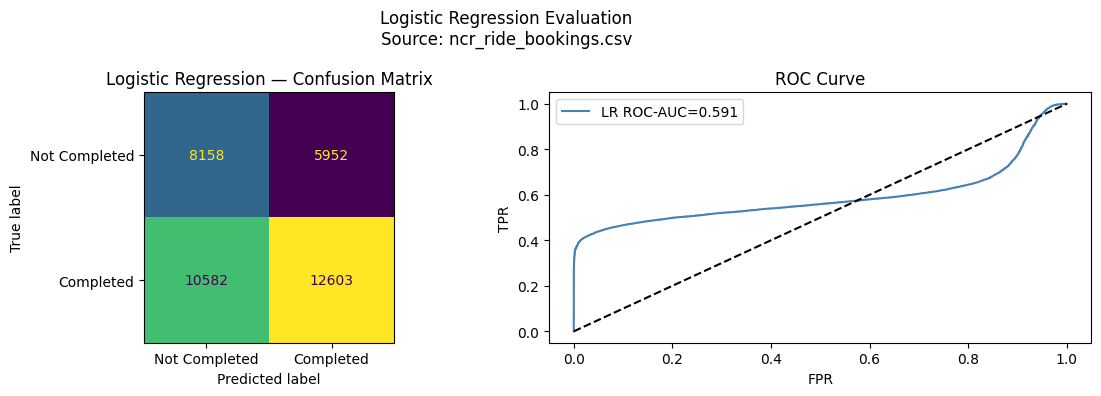

In [7]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
ConfusionMatrixDisplay(metrics_lr['confusion_matrix'],
    display_labels=['Not Completed','Completed']).plot(ax=axes[0], colorbar=False)
axes[0].set_title('Logistic Regression — Confusion Matrix')
axes[1].plot(metrics_lr['roc_fpr'], metrics_lr['roc_tpr'], color='steelblue',
             label=f'LR ROC-AUC={metrics_lr["roc_auc"]:.3f}')
axes[1].plot([0,1],[0,1],'k--'); axes[1].set_xlabel('FPR'); axes[1].set_ylabel('TPR')
axes[1].set_title('ROC Curve'); axes[1].legend()
fig.suptitle('Logistic Regression Evaluation\nSource: ncr_ride_bookings.csv')
plt.tight_layout()
fig.savefig('outputs/plots/11_lr_eval.png', dpi=150, bbox_inches='tight')
plt.show()

## 11.6 Stage 1 — Random Forest

In [8]:
pipe_rf = train_classify(X_train, y_train, model_name='random_forest')
metrics_rf = evaluate_classifier(pipe_rf, X_test, y_test, 'Random Forest')

[OK] Trained random_forest classifier → saved.

[EVAL] Random Forest
  ROC-AUC : 0.9795
  Avg Prec: 0.9867
              precision    recall  f1-score   support

           0       0.99      0.88      0.93     14110
           1       0.93      1.00      0.96     23185

    accuracy                           0.95     37295
   macro avg       0.96      0.94      0.95     37295
weighted avg       0.95      0.95      0.95     37295



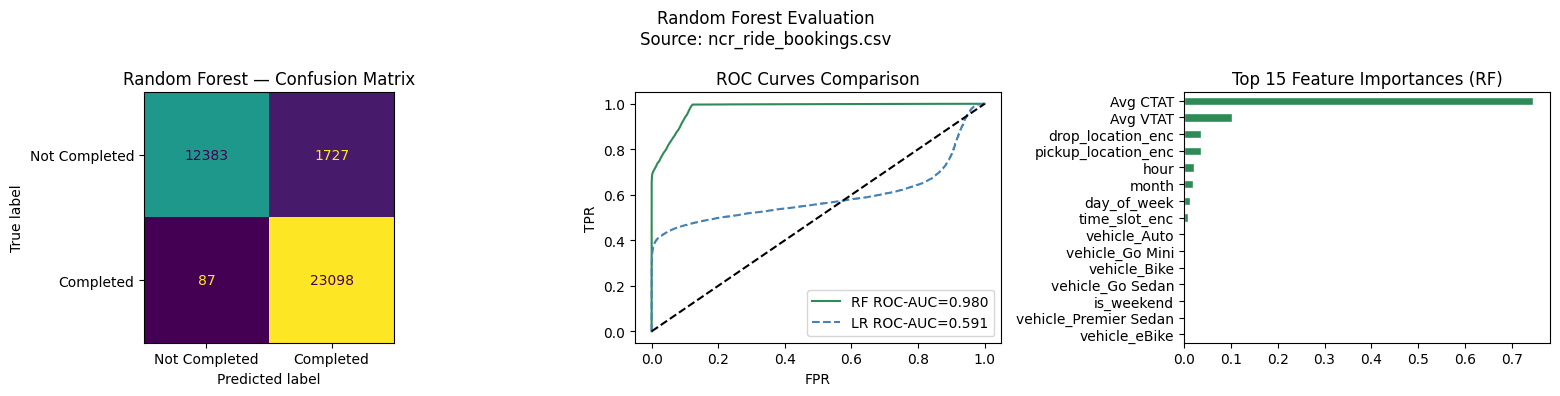

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
ConfusionMatrixDisplay(metrics_rf['confusion_matrix'],
    display_labels=['Not Completed','Completed']).plot(ax=axes[0], colorbar=False)
axes[0].set_title('Random Forest — Confusion Matrix')

axes[1].plot(metrics_rf['roc_fpr'], metrics_rf['roc_tpr'], color='seagreen',
             label=f'RF ROC-AUC={metrics_rf["roc_auc"]:.3f}')
axes[1].plot(metrics_lr['roc_fpr'], metrics_lr['roc_tpr'], color='steelblue', linestyle='--',
             label=f'LR ROC-AUC={metrics_lr["roc_auc"]:.3f}')
axes[1].plot([0,1],[0,1],'k--'); axes[1].set_xlabel('FPR'); axes[1].set_ylabel('TPR')
axes[1].set_title('ROC Curves Comparison'); axes[1].legend()

import numpy as np
rf_step = pipe_rf.named_steps['clf']
feat_imp = pd.Series(rf_step.feature_importances_, index=X_train.columns).sort_values(ascending=False).head(15)
feat_imp.plot(kind='barh', ax=axes[2], color='seagreen', edgecolor='white')
axes[2].set_title('Top 15 Feature Importances (RF)'); axes[2].invert_yaxis()

fig.suptitle('Random Forest Evaluation\nSource: ncr_ride_bookings.csv')
plt.tight_layout()
fig.savefig('outputs/plots/11_rf_eval.png', dpi=150, bbox_inches='tight')
plt.show()

## 11.7 Model Comparison & Business Interpretation

In [10]:
import pandas as pd
results = pd.DataFrame([
    {k: v for k, v in metrics_lr.items() if isinstance(v, (int,float,str))},
    {k: v for k, v in metrics_rf.items() if isinstance(v, (int,float,str))},
])
print('Model Comparison:')
print(results[['model','roc_auc','avg_precision','precision_1','recall_1','f1_1']].to_string(index=False))
results.to_csv('outputs/reports/ml_results_classification.csv', index=False)

print()
print('Business interpretation:')
for _, row in results.iterrows():
    auc = row['roc_auc']
    if auc >= 0.75:
        interp = 'strong discrimination — suitable for dispatch prioritisation'
    elif auc >= 0.65:
        interp = 'moderate discrimination — useful for risk flagging with caution'
    elif auc >= 0.55:
        interp = 'weak discrimination — limited operational use; investigate features'
    else:
        interp = 'near-random — not useful operationally; review feature set'
    print(f'  {row["model"]}: AUC={auc:.3f} → {interp}')

Model Comparison:
              model  roc_auc  avg_precision  precision_1  recall_1   f1_1
Logistic Regression   0.5907         0.7954       0.6792    0.5436 0.6039
      Random Forest   0.9795         0.9867       0.9304    0.9962 0.9622

Business interpretation:
  Logistic Regression: AUC=0.591 → weak discrimination — limited operational use; investigate features
  Random Forest: AUC=0.980 → strong discrimination — suitable for dispatch prioritisation


In [11]:
# Stage 2 decision gate
auc_gap = metrics_rf['roc_auc'] - metrics_lr['roc_auc']
best_auc = max(metrics_lr['roc_auc'], metrics_rf['roc_auc'])
print(f'LR AUC: {metrics_lr["roc_auc"]:.4f}  |  RF AUC: {metrics_rf["roc_auc"]:.4f}  |  Gap: {auc_gap:.4f}')
print()
if best_auc < 0.70 and auc_gap < 0.03:
    print('Stage 2 trigger consideration: best AUC is below 0.70 and LR→RF gap is small.')
    print('Consider gradient boosting (XGBoost/LightGBM) only if additional feature engineering')
    print('does not improve performance. Install requirements-optional.txt if proceeding.')
else:
    print('Stage 2 not required: Stage 1 models provide adequate or improving discrimination.')

LR AUC: 0.5907  |  RF AUC: 0.9795  |  Gap: 0.3888

Stage 2 not required: Stage 1 models provide adequate or improving discrimination.


## 11.8 Task B — Fare Estimation (Regression)

In [12]:
X_train_fare, y_train_fare = build_fare_features(train_df, encodings, global_fallback)
X_test_fare,  y_test_fare  = build_fare_features(test_df,  encodings, global_fallback)
print(f'Fare train: {X_train_fare.shape}  |  Test: {X_test_fare.shape}')
print(f'Fare target range (train): ₹{y_train_fare.min():.0f} – ₹{y_train_fare.max():.0f}')

Fare train: (69815, 13)  |  Test: (23185, 13)
Fare target range (train): ₹50 – ₹4228


In [13]:
pipe_lin = train_fare_model(X_train_fare, y_train_fare, model_name='linear')
metrics_lin = evaluate_regressor(pipe_lin, X_test_fare, y_test_fare, 'Linear Regression')

pipe_rfr = train_fare_model(X_train_fare, y_train_fare, model_name='random_forest')
metrics_rfr = evaluate_regressor(pipe_rfr, X_test_fare, y_test_fare, 'Random Forest Regressor')

[OK] Trained linear fare regressor → saved.

[EVAL] Linear Regression (fare regression)
  MAE : 281.01 INR
  RMSE: 399.26 INR
  R²  : 0.0352
[OK] Trained random_forest fare regressor → saved.

[EVAL] Random Forest Regressor (fare regression)
  MAE : 292.54 INR
  RMSE: 405.12 INR
  R²  : 0.0066


Fare Estimation Model Comparison:
                  model    mae   rmse     r2
      Linear Regression 281.01 399.26 0.0352
Random Forest Regressor 292.54 405.12 0.0066


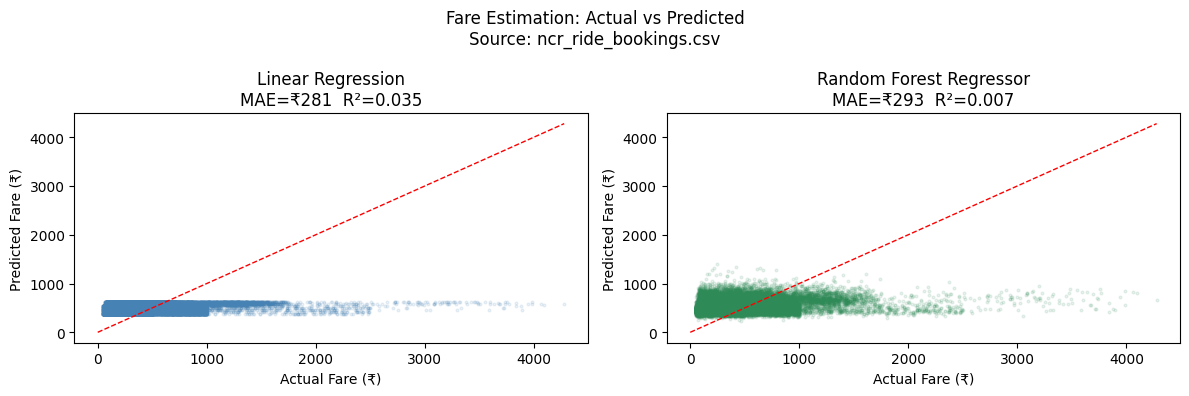

In [14]:
fare_results = pd.DataFrame([
    {k:v for k,v in metrics_lin.items() if isinstance(v,(int,float,str))},
    {k:v for k,v in metrics_rfr.items() if isinstance(v,(int,float,str))},
])
print('Fare Estimation Model Comparison:')
print(fare_results[['model','mae','rmse','r2']].to_string(index=False))
fare_results.to_csv('outputs/reports/ml_results_fare.csv', index=False)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for metrics, ax, color in [(metrics_lin, axes[0], 'steelblue'),
                            (metrics_rfr, axes[1], 'seagreen')]:
    y_pred = metrics['y_pred']
    ax.scatter(y_test_fare, y_pred, alpha=0.1, s=4, color=color)
    mx = max(y_test_fare.max(), y_pred.max())
    ax.plot([0, mx], [0, mx], 'r--', lw=1)
    ax.set_title(f'{metrics["model"]}\nMAE=₹{metrics["mae"]:.0f}  R²={metrics["r2"]:.3f}')
    ax.set_xlabel('Actual Fare (₹)'); ax.set_ylabel('Predicted Fare (₹)')
fig.suptitle('Fare Estimation: Actual vs Predicted\nSource: ncr_ride_bookings.csv')
plt.tight_layout()
fig.savefig('outputs/plots/11_fare_prediction.png', dpi=150, bbox_inches='tight')
plt.show()

## Limitations
- All post-outcome columns (Booking Value, Ride Distance, ratings, payment) are excluded from Task A.
- No hardcoded pass/fail AUC threshold — performance is interpreted in business context above.
- Stage 2 (XGBoost, LightGBM, SHAP) is optional and triggered only if Stage 1 results justify it.
- CAC, LTV, ROAS, driver payout, and cost metrics are unavailable and not used.

# Part 12: 12 Prescriptive Analytics

# Notebook 12 — Prescriptive Analytics

**Tier:** 4 — Prescriptive (What should we do?)  
**Purpose:** Convert insights from Tiers 1–3 into actionable recommendations with quantified scenario estimates.  
**Input:** `outputs/feature_store.parquet`, outputs from prior notebooks  
**Output:** `outputs/reports/prescriptions.csv`, charts  

> **Important:** Scenario estimates are directional upper bounds only.  
> CAC, LTV, ROAS, driver payout, commission, operating cost, and contribution margin
> are **unavailable** — all prescriptions are revenue-side only (Gross Booking Value).
> ROI cannot be quantified without cost data.

In [20]:
import os
os.chdir(r"D:\projects\Uber_Data_India_Analytics")
import sys, warnings, pathlib
sys.path.insert(0, '..')
warnings.filterwarnings('ignore')
pathlib.Path('outputs/plots').mkdir(parents=True, exist_ok=True)
pathlib.Path('outputs/reports').mkdir(parents=True, exist_ok=True)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

df = pd.read_parquet('outputs/feature_store.parquet')
completed = df[df['is_completed']].copy()
slot_order = ['Early Morning','Morning','Afternoon','Evening','Night','Late Night']
month_labels = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
print(f'Loaded feature store: {df.shape}  |  completed: {len(completed):,}')

Loaded feature store: (150000, 46)  |  completed: 93,000


## 12.1 Supply Optimisation Prescriptions

In [21]:
# Identify top (zone, time_slot) cells with highest No-Driver-Found rate
ndf = df.groupby(['pickup_zone','time_slot'], observed=True).agg(
    total=('Booking ID','count'),
    ndf_count=('Booking Status', lambda s: (s=='No Driver Found').sum()),
).reset_index()
ndf['ndf_rate_pct'] = (ndf['ndf_count'] / ndf['total'] * 100).round(1)
ndf = ndf[ndf['total'] >= 50].sort_values('ndf_rate_pct', ascending=False).head(10)
print('Top 10 (Zone, Time Slot) cells by No-Driver-Found rate (min 50 bookings):')
print(ndf.to_string(index=False))

Top 10 (Zone, Time Slot) cells by No-Driver-Found rate (min 50 bookings):
pickup_zone     time_slot  total  ndf_count  ndf_rate_pct
  Faridabad       Evening    259         24           9.3
  Faridabad Early Morning     57          5           8.8
  Outer NCR Early Morning    362         32           8.8
  Faridabad     Afternoon    154         13           8.4
  Outer NCR    Late Night     97          8           8.2
  Outer NCR       Evening   1725        139           8.1
    Gurgaon    Late Night    323         26           8.0
Delhi North Early Morning   1256         99           7.9
      Noida Early Morning    525         41           7.8
Delhi South Early Morning   1415        110           7.8


In [22]:
# Scenario: reduce NDF rate in top cells by 20% → estimated additional rides × median fare
median_fare = completed['Booking Value'].median()
avg_fare = completed['Booking Value'].mean()

ndf['scenario_extra_rides'] = (ndf['ndf_count'] * 0.20).round(0).astype(int)
ndf['scenario_gbv_uplift'] = (ndf['scenario_extra_rides'] * median_fare).round(0)
print('Scenario: 20% NDF reduction in top cells (using median fare ₹{:.0f}):'.format(median_fare))
print(ndf[['pickup_zone','time_slot','ndf_count','scenario_extra_rides','scenario_gbv_uplift']].to_string(index=False))
print(f'\nTotal scenario GBV uplift: ₹{ndf["scenario_gbv_uplift"].sum():,.0f}')
print()
print('⚠ SCENARIO ESTIMATE ONLY — assumes recovered rides complete at median fare.')
print('  Actual uplift depends on whether drivers are available and rides complete.')
print('  Net revenue impact cannot be calculated (no driver payout or cost data).')

Scenario: 20% NDF reduction in top cells (using median fare ₹414):
pickup_zone     time_slot  ndf_count  scenario_extra_rides  scenario_gbv_uplift
  Faridabad       Evening         24                     5               2070.0
  Faridabad Early Morning          5                     1                414.0
  Outer NCR Early Morning         32                     6               2484.0
  Faridabad     Afternoon         13                     3               1242.0
  Outer NCR    Late Night          8                     2                828.0
  Outer NCR       Evening        139                    28              11592.0
    Gurgaon    Late Night         26                     5               2070.0
Delhi North Early Morning         99                    20               8280.0
      Noida Early Morning         41                     8               3312.0
Delhi South Early Morning        110                    22               9108.0

Total scenario GBV uplift: ₹41,400

⚠ SCENARIO ESTIM

## 12.2 Cancellation Reduction Prescriptions

In [23]:
# Customer cancellation: VTAT effect
cust_canc = df[df['Booking Status'] == 'Cancelled by Customer'].copy()
all_dispatched = df[df['Avg VTAT'].notna()].copy()
avg_vtat_canc = cust_canc['Avg VTAT'].dropna().mean()
avg_vtat_all  = all_dispatched['Avg VTAT'].mean()

print(f'Avg VTAT — customer-cancelled: {avg_vtat_canc:.2f} min')
print(f'Avg VTAT — all dispatched    : {avg_vtat_all:.2f} min')

# Scenario: reduce customer cancellation rate by 10%
n_cust_canc = len(cust_canc)
scenario_saved = int(n_cust_canc * 0.10)
scenario_gbv = scenario_saved * median_fare
print(f'\nScenario: 10% reduction in customer cancellations → {scenario_saved:,} extra rides')
print(f'Estimated GBV uplift: ₹{scenario_gbv:,.0f}  (at median fare — upper-bound estimate)')
print()
print('Recommended interventions:')
print('  1. Alert driver if VTAT exceeds threshold (~12 min) to prompt movement toward pickup.')
print('  2. Monitor "driver not moving" cases (reason category) and surface in driver app.')
print('  3. Notify customer with ETA update if VTAT exceeds 10 min to manage expectations.')

Avg VTAT — customer-cancelled: 12.51 min
Avg VTAT — all dispatched    : 8.46 min

Scenario: 10% reduction in customer cancellations → 1,050 extra rides
Estimated GBV uplift: ₹434,700  (at median fare — upper-bound estimate)

Recommended interventions:
  1. Alert driver if VTAT exceeds threshold (~12 min) to prompt movement toward pickup.
  2. Monitor "driver not moving" cases (reason category) and surface in driver app.
  3. Notify customer with ETA update if VTAT exceeds 10 min to manage expectations.


## 12.3 Customer Retention Prescriptions

In [24]:
from src.cohort import build_cohort_retention, build_cohort_retention_rate, avg_retention_curve

count_matrix = build_cohort_retention(df)
rate_matrix  = build_cohort_retention_rate(count_matrix)
curve        = avg_retention_curve(rate_matrix)

if 0 in curve.index and 1 in curve.index:
    m1_ret = curve[1]
    drop = curve[0] - m1_ret
    print(f'Month-0 retention: {curve[0]:.1f}%')
    print(f'Month-1 retention: {m1_ret:.1f}%')
    print(f'Month-0 → Month-1 drop: {drop:.1f} pp  ← primary churn event')
    print()
    print('Prescription: Re-engagement notification at Day 7 after first ride.')
    print('Target: increase Month-1 retention from {:.1f}% toward benchmark.'.format(m1_ret))
    print()
    print('NOTE: Revenue impact of retention actions cannot be quantified without CAC data.')
    print('      Prescriptions are directional — ROI requires cost-side data.')

Month-0 retention: 100.0%
Month-1 retention: 0.1%
Month-0 → Month-1 drop: 99.9 pp  ← primary churn event

Prescription: Re-engagement notification at Day 7 after first ride.
Target: increase Month-1 retention from 0.1% toward benchmark.

NOTE: Revenue impact of retention actions cannot be quantified without CAC data.
      Prescriptions are directional — ROI requires cost-side data.


In [25]:
from src.segmentation import build_rfm
rfm = build_rfm(df)
seg_actions = {
    'Champion'          : 'Loyalty tier recognition; priority support; early access to new features.',
    'Loyal'             : 'Reward milestone (e.g. 10th ride discount); referral incentive.',
    'Potential Loyalist': 'Second-ride incentive within 14 days of first booking.',
    'New Customer'      : 'Onboarding message + second-ride discount at Day 7.',
    'At Risk'           : 'Re-engagement offer; personalised push notification.',
    'Hibernating'       : 'Win-back campaign with time-limited discount.',
    'Lost'              : 'Minimal spend; opt-out from paid campaigns until re-activated.',
}
seg_counts = rfm['rfm_segment'].value_counts()
print('RFM Segment Actions:')
for seg, action in seg_actions.items():
    count = seg_counts.get(seg, 0)
    print(f'  {seg:22s} ({count:,} customers): {action}')
print()
print('NOTE: CAC and LTV are unavailable. All prescriptions are directional.')

RFM Segment Actions:
  Champion               (2,129 customers): Loyalty tier recognition; priority support; early access to new features.
  Loyal                  (35,486 customers): Reward milestone (e.g. 10th ride discount); referral incentive.
  Potential Loyalist     (37,182 customers): Second-ride incentive within 14 days of first booking.
  New Customer           (0 customers): Onboarding message + second-ride discount at Day 7.
  At Risk                (27,711 customers): Re-engagement offer; personalised push notification.
  Hibernating            (9,306 customers): Win-back campaign with time-limited discount.
  Lost                   (36,974 customers): Minimal spend; opt-out from paid campaigns until re-activated.

NOTE: CAC and LTV are unavailable. All prescriptions are directional.


## 12.4 Peak Hour Demand Management

In [26]:
# Demand-supply gap index by hour: bookings / completed rides
hourly_gap = df.groupby('hour').agg(
    bookings=('Booking ID','count'),
    completed=('is_completed','sum'),
).assign(gap_index=lambda x: (x['bookings'] / x['completed'].replace(0,1)).round(2))
hourly_gap = hourly_gap.sort_values('gap_index', ascending=False)
print('Hours with highest demand-supply gap (bookings per completed ride):')
print(hourly_gap.head(6).to_string())
print()
print('Prescription: Consider dynamic pricing (surge) during peak gap hours.')
print('Prescription: Driver scheduling incentives for hours with gap_index > 1.5.')

Hours with highest demand-supply gap (bookings per completed ride):
      bookings  completed  gap_index
hour                                
1         1360        828       1.64
7         5450       3346       1.63
19       11047       6798       1.63
14        7031       4310       1.63
18       12397       7617       1.63
9         8234       5084       1.62

Prescription: Consider dynamic pricing (surge) during peak gap hours.
Prescription: Driver scheduling incentives for hours with gap_index > 1.5.


## 12.5 Payment Mix Optimisation

In [27]:
payment_dist = completed['Payment Method'].value_counts()
cash_pct = payment_dist.get('Cash', 0) / payment_dist.sum() * 100
upi_pct  = payment_dist.get('UPI',  0) / payment_dist.sum() * 100
print(f'UPI  : {upi_pct:.1f}% of completed rides')
print(f'Cash : {cash_pct:.1f}% of completed rides')
print()
print('Prescriptions:')
print('  1. UPI cashback or loyalty points to consolidate UPI dominance.')
print('  2. In-app nudge + incentive on cash rides to migrate to digital payment.')
print('  3. Focus cash-to-digital migration on top cash-heavy routes (see Notebook 07).')

UPI  : 45.0% of completed rides
Cash : 24.9% of completed rides

Prescriptions:
  1. UPI cashback or loyalty points to consolidate UPI dominance.
  2. In-app nudge + incentive on cash rides to migrate to digital payment.
  3. Focus cash-to-digital migration on top cash-heavy routes (see Notebook 07).


## 12.6 Prescription Summary

In [28]:
prescriptions = [
    {'area': 'Supply Optimisation',     'action': 'Driver incentives in top NDF (zone, slot) cells',
     'scenario_gbv_uplift_inr': int(ndf['scenario_gbv_uplift'].sum()),
     'confidence': 'Upper-bound estimate', 'requires_cost_data': False},
    {'area': 'Cancellation Reduction',  'action': '10% customer cancellation reduction (VTAT alerts)',
     'scenario_gbv_uplift_inr': int(scenario_gbv),
     'confidence': 'Upper-bound estimate', 'requires_cost_data': False},
    {'area': 'Retention',               'action': 'Day-7 re-engagement for all new customers',
     'scenario_gbv_uplift_inr': None,
     'confidence': 'Directional only — CAC/cost data needed for ROI', 'requires_cost_data': True},
    {'area': 'Peak Demand',             'action': 'Surge pricing / driver scheduling for high-gap hours',
     'scenario_gbv_uplift_inr': None,
     'confidence': 'Directional only — pricing model needed', 'requires_cost_data': False},
    {'area': 'Payment Mix',             'action': 'UPI cashback; cash-to-digital migration',
     'scenario_gbv_uplift_inr': None,
     'confidence': 'Directional only — incentive cost data needed', 'requires_cost_data': True},
]
presc_df = pd.DataFrame(prescriptions)
print(presc_df.to_string(index=False))
presc_df.to_csv('outputs/reports/prescriptions.csv', index=False)
print('\nSaved: outputs/reports/prescriptions.csv')

                  area                                               action  scenario_gbv_uplift_inr                                      confidence  requires_cost_data
   Supply Optimisation      Driver incentives in top NDF (zone, slot) cells                  41400.0                            Upper-bound estimate               False
Cancellation Reduction    10% customer cancellation reduction (VTAT alerts)                 434700.0                            Upper-bound estimate               False
             Retention            Day-7 re-engagement for all new customers                      NaN Directional only — CAC/cost data needed for ROI                True
           Peak Demand Surge pricing / driver scheduling for high-gap hours                      NaN         Directional only — pricing model needed               False
           Payment Mix              UPI cashback; cash-to-digital migration                      NaN   Directional only — incentive cost data needed       

## Unavailable Metrics (documented)

| Metric | Why unavailable |
|---|---|
| CAC | No acquisition channel or marketing spend field |
| LTV | No cost-side data; cannot compute net margin |
| ROAS | No ad spend data |
| Driver payout | No payout rate or amount field |
| Platform commission | No commission rate field |
| Operating cost | No cost data of any kind |
| Contribution margin | Requires revenue minus variable cost; cost absent |

These metrics would require additional data from financial and CRM systems not included in this dataset.